<a href="https://colab.research.google.com/github/UrsulaM25/ProyectoDSIIParteI_Macedo/blob/main/ProyectoDSIIParteII_Macedo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 1. Introducción

Analizar la oferta y demanda de energía eléctrica a lo largo del tiempo no solo
permite detectar tendencias y estacionalidades,sino que también permite comprender como se despacha la energía en diferentes contextos. Esta información resulta clave a la hora de tomar decisiones para gestionar la demanda y oferta de manera eficiente, prever picos de consumo y planificar en consecuencia reduciendo riesgos de desabastecimiento y optimizando los recursos disponibles.

Por ello, en base a la variabilidad y estacionalidad de la generación y la demanda de la población, la empresa busca predecir la importación de energía de paises vecinos para gestionar las compras minimizando los costos y riesgos.


#2. Dataset

Se seleccionó un dataframe que contiene datos de oferta y demanda de energía eléctrica en Argentina desde el año 2022 a 2024, los mismos provienen de la página de CAMMESA (organismo encargado de operar el mercado eléctrico mayorista en Argentina).

Sus columnas contienen los siguientes datos:

Año: año de demanda

mes: mes de demanda, formato mes-año

n° mes

n° día

Tipo de día: hábil, no hábil

día: Dia de la semana

fecha: formato día/mes/año

hora

Nuclear           (MWh): Datos de generación nuclear en MWh

Biogas            (MWh): Datos de generación por Biogas en MWh

Biomasa           (MWh): Datos de generación por Biomasa en MWh

Eólica            (MWh): Datos de generación eólica en MWh

Hidráulica > 50   (MWh): Datos de generación hidroelectrica mayor a 50 MW en MWh

Hidráulica < 50   (MWh): Datos de generación hidroelectrica menor a 50 MW en MWh

Solar             (MWh): Datos de generación solar en MWh

Ciclos Combinados (MWh): Datos de generación de CC en MWh

Motor Diesel      (MWh): Datos de generación Motor Diesel en MWh

Turbina a gas     (MWh): Datos de generación TG en MWh

Turbovapor        (MWh): Datos de generación TV en MWh

Importación       (MWh): Datos energía importada

GENERACION TOTAL  (MWh): Suma de MWh de fuentes de generación

Gran Usuario MEM  (MWh): Demanda de grandes usuarios en MWh, la misma está compuesta por la demanda de la categoría GUMA (Gran Usuario Mayorista Autogenerador) como ejemplo se pueden mencionar las demandas de las empresas Arcor, Acindar, aysa, molinos cañuelas entre otras.

DISTRIBUIDOR (demanda estacional+GUMEs)  (MWh): La categoría distribuidor comprende la demanda en MWh de la demanda estacional y las GUMEs (Grandes Usuarios Menores) como ejemplo se pueden mencionar cooperativas, Edelap, Edenor, Edesur, EPEC entre otros.

DEMANDA LOCAL [MWh]:  La demanda local es la suma de las demandas Gran Usuario MEM y Distribuidor (demanda estacional+GUMEs)







# 3. Importar Librerias

In [1]:
# Importación de lLibrerías

import pandas as pd
import numpy as np


#Visualizaciones
import missingno as msno
import matplotlib.pyplot as plt
import seaborn as sns

#Imputacion y transformaciones
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder
from sklearn.compose import ColumnTransformer

#Modelos
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.model_selection import TimeSeriesSplit
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import AdaBoostRegressor
from lightgbm import LGBMRegressor
from xgboost import XGBRegressor
from sklearn.pipeline import Pipeline
import joblib

!pip install scikit-optimize
from skopt import BayesSearchCV


# Evaluacion
from sklearn.metrics import accuracy_score
from sklearn.metrics import mean_squared_error,mean_absolute_percentage_error, mean_absolute_error, r2_score, median_absolute_error
from sklearn.model_selection import cross_validate
from sklearn.metrics import make_scorer


#Visualización interactiva
from matplotlib.animation import FuncAnimation
import plotly.express as px
import plotly.graph_objects as go


#Eliminar warnings
import warnings
warnings.filterwarnings('ignore')

#Configuraciones adicionales
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)


# 4. Carga de datos

In [2]:
df = pd.read_csv ("https://raw.githubusercontent.com/UrsulaM25/ProyectoDSIIParteI_Macedo/refs/heads/main/Demanda_Oferta_horaria_CSV.csv", delimiter=";",decimal=",")  # Especifico el delimitador y agrego el CSV

In [3]:
df.shape #tamaño de dataframe

(26304, 24)

In [4]:
df.size #Cantidad de datos

631296

# 5. Data wrangling

In [5]:
df.info () #Info df

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 26304 entries, 0 to 26303
Data columns (total 24 columns):
 #   Column                                          Non-Null Count  Dtype  
---  ------                                          --------------  -----  
 0   AÑO                                             26304 non-null  int64  
 1   MES                                             26304 non-null  object 
 2   N° MES                                          26304 non-null  int64  
 3   N° DIA                                          26304 non-null  int64  
 4   TIPO DIA                                        26304 non-null  object 
 5   DIA                                             26304 non-null  object 
 6   FECHA                                           26304 non-null  object 
 7   HORA                                            26304 non-null  int64  
 8   Nuclear (MWh)                                   26304 non-null  float64
 9   Biogas (MWh)                           

In [6]:
df.describe () #Info df

,AÑO,N° MES,N° DIA,HORA,Nuclear (MWh),Biogas (MWh),Biomasa (MWh),Eólica (MWh),Hidráulica > 50 (MWh),Hidráulica < 50 (MWh),Solar (MWh),Ciclos Combinados (MWh),Motor Diesel (MWh),Turbina a gas (MWh),Turbovapor (MWh),Importación (MWh),GENERACION TOTAL [MWh],Gran Usuario MEM (MWh),DISTRIBUIDOR (demanda estacional+GUMEs) (MWh),DEMANDA LOCAL [MWh]
count,26304.000000,26304.000000,26304.000000,26304.000000,26304.000000,26304.000000,26304.000000,26304.000000,26304.000000,26304.000000,26304.000000,26304.000000,26304.000000,26304.000000,26304.000000,26304.000000,26304.000000,26304.000000,26304.000000,26304.000000
mean,2023.000912,6.521898,15.732664,12.500000,1021.943081,51.902085,85.485689,1703.329923,3913.556156,142.772102,385.077138,7211.325614,226.443749,760.610127,551.589460,654.061771,16708.096896,2115.297939,13847.224415,15962.522354
std,0.816698,3.449052,8.801537,6.922318,399.316061,6.298146,19.194047,631.504332,1534.178073,54.508154,463.268274,1484.758080,221.050342,552.909763,429.179705,726.896354,2941.348364,195.718895,2824.949398,2870.258213
min,2022.000000,1.000000,1.000000,1.000000,0.000000,15.589000,20.694000,112.518000,1034.723000,44.258000,0.000000,3177.443000,23.064000,68.258000,0.000000,0.000000,10059.670000,1203.000000,7735.000000,9282.000000
25%,2022.000000,4.000000,8.000000,6.750000,924.535750,47.035000,76.388000,1247.775750,2680.828750,91.698250,0.000000,6082.460000,61.382000,395.139750,189.619250,14.950000,14568.505750,1992.000000,11823.000000,13885.000000
50%,2023.000000,7.000000,16.000000,12.500000,944.499000,51.518000,84.183500,1708.017000,3701.931000,142.853500,18.343500,7163.403500,130.693500,579.764000,480.811500,311.705000,16342.899000,2143.000000,13475.000000,15617.500000
75%,2024.000000,10.000000,23.000000,18.250000,1323.467750,57.493250,99.434000,2175.820000,5062.347250,182.439500,832.051000,8349.911000,356.447250,1005.561250,853.461500,1264.622500,18512.595500,2251.000000,15590.000000,17729.000000
max,2024.000000,12.000000,31.000000,24.000000,1611.693000,65.650000,133.561000,3470.656000,8493.314000,291.537000,1609.526000,11560.524000,1379.237000,3773.587000,2139.857000,3328.290000,28689.406000,2698.000000,25422.000000,27433.000000


## 5.1 Formatos (df_base1)

Se verifican formatos y/o aplicar cambios al df  original

In [7]:
df

,AÑO,MES,N° MES,N° DIA,TIPO DIA,DIA,FECHA,HORA,Nuclear (MWh),Biogas (MWh),Biomasa (MWh),Eólica (MWh),Hidráulica > 50 (MWh),Hidráulica < 50 (MWh),Solar (MWh),Ciclos Combinados (MWh),Motor Diesel (MWh),Turbina a gas (MWh),Turbovapor (MWh),Importación (MWh),GENERACION TOTAL [MWh],Gran Usuario MEM (MWh),DISTRIBUIDOR (demanda estacional+GUMEs) (MWh),DEMANDA LOCAL [MWh]
0,2022,ene-22,1,1,No Hábil,Sábado,1/1/2022,1,1357.060,48.098,67.429,1649.507,1678.081,110.497,0.000,8884.915,264.439,1215.024,1100.361,278.204,16653.615,1266,14628,15894
1,2022,ene-22,1,1,No Hábil,Sábado,1/1/2022,2,1360.842,47.729,50.870,1529.287,1744.359,111.797,0.000,9269.344,238.832,1123.293,1100.440,232.120,16808.913,1264,14703,15967
2,2022,ene-22,1,1,No Hábil,Sábado,1/1/2022,3,1359.371,47.745,45.193,1490.881,1570.168,110.453,0.000,9711.728,237.449,1113.151,1091.554,222.778,17000.471,1296,14950,16246
3,2022,ene-22,1,1,No Hábil,Sábado,1/1/2022,4,1357.517,46.755,45.664,1848.192,1558.943,110.664,0.000,9598.543,235.638,1120.335,1089.965,276.418,17288.634,1295,15020,16315
4,2022,ene-22,1,1,No Hábil,Sábado,1/1/2022,5,1358.948,46.883,46.031,2270.724,1574.759,111.008,0.000,9040.523,238.270,1044.805,1093.251,291.968,17117.170,1291,14814,16105
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
26299,2024,dic-24,12,31,Hábil,Martes,31/12/2024,20,1139.181,54.986,86.832,2259.766,4226.993,153.553,288.373,8792.182,172.199,761.922,373.344,0.028,18309.359,1413,16162,17575
26300,2024,dic-24,12,31,Hábil,Martes,31/12/2024,21,1139.984,55.428,82.761,2255.846,4528.189,170.953,20.168,8982.498,176.392,899.281,322.530,0.028,18634.058,1399,16482,17881
26301,2024,dic-24,12,31,Hábil,Martes,31/12/2024,22,1140.962,55.535,83.628,1972.647,4107.739,165.030,0.000,9045.500,181.909,883.725,312.528,0.022,17949.225,1381,15993,17374
26302,2024,dic-24,12,31,Hábil,Martes,31/12/2024,23,1139.501,55.642,81.527,1935.492,3314.324,176.739,0.000,8737.521,130.123,549.258,215.099,0.022,16335.248,1366,14496,15862


In [8]:
df_base1=df.copy()

Se cambian los nombres de las columnas para facilitar el análisis sobre df_base

In [9]:
#Normalizo formatos
df_base1['TIPO DIA'] = df_base1['TIPO DIA'].replace({'No hábil':'No Hábil'})

# Renombrar columnas
df_base1 = df_base1.rename(columns={'DISTRIBUIDOR (demanda estacional+GUMEs)  (MWh)':'DISTRIBUIDOR', 'DEMANDA LOCAL [MWh]': 'DEMANDALOCAL', 'N° MES':'NUMMES','N° DIA':'NUMDIA','TIPO DIA':'TIPODIA','Nuclear (MWh)':'NUCLEAR','Biogas (MWh)': 'BIOGAS', 'Biomasa (MWh)': 'BIOMASA', 'Eólica (MWh)':'EOLICA','Hidráulica > 50  (MWh)':'HIDRO_MAS_50','Hidráulica < 50 (MWh)':'HIDRO_MENOS_50','Solar (MWh)':'SOLAR','Ciclos Combinados (MWh)':'CC','Motor Diesel (MWh)':'MDIESEL','Turbina a gas (MWh)':'TG','Turbovapor (MWh)':'TV','Importación (MWh)':'IMPORTACION','GENERACION TOTAL [MWh]':'GENERACIONTOTAL','Gran Usuario MEM  (MWh)':'GRANUSUARIO'
             })


In [10]:
print(df_base1.dtypes) #Verificar tipo de datos

AÑO                  int64
MES                 object
NUMMES               int64
NUMDIA               int64
TIPODIA             object
DIA                 object
FECHA               object
HORA                 int64
NUCLEAR            float64
BIOGAS             float64
BIOMASA            float64
EOLICA             float64
HIDRO_MAS_50       float64
HIDRO_MENOS_50     float64
SOLAR              float64
CC                 float64
MDIESEL            float64
TG                 float64
TV                 float64
IMPORTACION        float64
GENERACIONTOTAL    float64
GRANUSUARIO          int64
DISTRIBUIDOR         int64
DEMANDALOCAL         int64
dtype: object


Se cambia  el formato fecha y enteros

In [11]:
df_base1["FECHA"] = pd.to_datetime(df_base1["FECHA"], format="%d/%m/%Y") #Cambiar tipo de dato de fecha a fecha

df_base1.dtypes['FECHA']


dtype('<M8[ns]')

In [12]:
columnas_a_convertir=['GRANUSUARIO','DISTRIBUIDOR','DEMANDALOCAL']

df_base1[columnas_a_convertir] = df_base1[columnas_a_convertir].astype(float) #convertir columnas a float

In [13]:
print(df_base1.dtypes)  # Verificar el tipo de datos

AÑO                         int64
MES                        object
NUMMES                      int64
NUMDIA                      int64
TIPODIA                    object
DIA                        object
FECHA              datetime64[ns]
HORA                        int64
NUCLEAR                   float64
BIOGAS                    float64
BIOMASA                   float64
EOLICA                    float64
HIDRO_MAS_50              float64
HIDRO_MENOS_50            float64
SOLAR                     float64
CC                        float64
MDIESEL                   float64
TG                        float64
TV                        float64
IMPORTACION               float64
GENERACIONTOTAL           float64
GRANUSUARIO               float64
DISTRIBUIDOR              float64
DEMANDALOCAL              float64
dtype: object


In [14]:
# Se agrega una columna que resuma la fecha
df_base1['FECHATOTAL'] = df_base1['FECHA'].dt.strftime("%d/%m/%Y") + " " + df_base1['HORA'].astype(str) + ":00:00"

print(df_base1[['FECHA', 'HORA', 'FECHATOTAL']].head())



       FECHA  HORA          FECHATOTAL
0 2022-01-01     1  01/01/2022 1:00:00
1 2022-01-01     2  01/01/2022 2:00:00
2 2022-01-01     3  01/01/2022 3:00:00
3 2022-01-01     4  01/01/2022 4:00:00
4 2022-01-01     5  01/01/2022 5:00:00


In [15]:
# Se reemplaza el indice por fecha total
df_base1.set_index('FECHATOTAL', inplace=True)



In [16]:
df_base1

,AÑO,MES,NUMMES,NUMDIA,TIPODIA,DIA,FECHA,HORA,NUCLEAR,BIOGAS,BIOMASA,EOLICA,HIDRO_MAS_50,HIDRO_MENOS_50,SOLAR,CC,MDIESEL,TG,TV,IMPORTACION,GENERACIONTOTAL,GRANUSUARIO,DISTRIBUIDOR,DEMANDALOCAL
FECHATOTAL,,,,,,,,,,,,,,,,,,,,,,,,
01/01/2022 1:00:00,2022,ene-22,1,1,No Hábil,Sábado,2022-01-01,1,1357.060,48.098,67.429,1649.507,1678.081,110.497,0.000,8884.915,264.439,1215.024,1100.361,278.204,16653.615,1266.0,14628.0,15894.0
01/01/2022 2:00:00,2022,ene-22,1,1,No Hábil,Sábado,2022-01-01,2,1360.842,47.729,50.870,1529.287,1744.359,111.797,0.000,9269.344,238.832,1123.293,1100.440,232.120,16808.913,1264.0,14703.0,15967.0
01/01/2022 3:00:00,2022,ene-22,1,1,No Hábil,Sábado,2022-01-01,3,1359.371,47.745,45.193,1490.881,1570.168,110.453,0.000,9711.728,237.449,1113.151,1091.554,222.778,17000.471,1296.0,14950.0,16246.0
01/01/2022 4:00:00,2022,ene-22,1,1,No Hábil,Sábado,2022-01-01,4,1357.517,46.755,45.664,1848.192,1558.943,110.664,0.000,9598.543,235.638,1120.335,1089.965,276.418,17288.634,1295.0,15020.0,16315.0
01/01/2022 5:00:00,2022,ene-22,1,1,No Hábil,Sábado,2022-01-01,5,1358.948,46.883,46.031,2270.724,1574.759,111.008,0.000,9040.523,238.270,1044.805,1093.251,291.968,17117.170,1291.0,14814.0,16105.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
31/12/2024 20:00:00,2024,dic-24,12,31,Hábil,Martes,2024-12-31,20,1139.181,54.986,86.832,2259.766,4226.993,153.553,288.373,8792.182,172.199,761.922,373.344,0.028,18309.359,1413.0,16162.0,17575.0
31/12/2024 21:00:00,2024,dic-24,12,31,Hábil,Martes,2024-12-31,21,1139.984,55.428,82.761,2255.846,4528.189,170.953,20.168,8982.498,176.392,899.281,322.530,0.028,18634.058,1399.0,16482.0,17881.0
31/12/2024 22:00:00,2024,dic-24,12,31,Hábil,Martes,2024-12-31,22,1140.962,55.535,83.628,1972.647,4107.739,165.030,0.000,9045.500,181.909,883.725,312.528,0.022,17949.225,1381.0,15993.0,17374.0


## 5.2 Agregar, eliminar columnas y generar nuevas variables (df_base)

In [17]:
df_base=df_base1.copy()

In [18]:
df_base.head()

,AÑO,MES,NUMMES,NUMDIA,TIPODIA,DIA,FECHA,HORA,NUCLEAR,BIOGAS,BIOMASA,EOLICA,HIDRO_MAS_50,HIDRO_MENOS_50,SOLAR,CC,MDIESEL,TG,TV,IMPORTACION,GENERACIONTOTAL,GRANUSUARIO,DISTRIBUIDOR,DEMANDALOCAL
FECHATOTAL,,,,,,,,,,,,,,,,,,,,,,,,
01/01/2022 1:00:00,2022,ene-22,1,1,No Hábil,Sábado,2022-01-01,1,1357.060,48.098,67.429,1649.507,1678.081,110.497,0.0,8884.915,264.439,1215.024,1100.361,278.204,16653.615,1266.0,14628.0,15894.0
01/01/2022 2:00:00,2022,ene-22,1,1,No Hábil,Sábado,2022-01-01,2,1360.842,47.729,50.870,1529.287,1744.359,111.797,0.0,9269.344,238.832,1123.293,1100.440,232.120,16808.913,1264.0,14703.0,15967.0
01/01/2022 3:00:00,2022,ene-22,1,1,No Hábil,Sábado,2022-01-01,3,1359.371,47.745,45.193,1490.881,1570.168,110.453,0.0,9711.728,237.449,1113.151,1091.554,222.778,17000.471,1296.0,14950.0,16246.0
01/01/2022 4:00:00,2022,ene-22,1,1,No Hábil,Sábado,2022-01-01,4,1357.517,46.755,45.664,1848.192,1558.943,110.664,0.0,9598.543,235.638,1120.335,1089.965,276.418,17288.634,1295.0,15020.0,16315.0
01/01/2022 5:00:00,2022,ene-22,1,1,No Hábil,Sábado,2022-01-01,5,1358.948,46.883,46.031,2270.724,1574.759,111.008,0.0,9040.523,238.270,1044.805,1093.251,291.968,17117.170,1291.0,14814.0,16105.0


In [19]:
# Eliminar una columna
# axis=1 indica que queremos eliminar una columna (axis=0 sería una fila)
df_base= df_base.drop(['MES','NUMDIA','NUMMES','DIA','GRANUSUARIO','DISTRIBUIDOR'], axis=1)

In [20]:
df_base.head()

,AÑO,TIPODIA,FECHA,HORA,NUCLEAR,BIOGAS,BIOMASA,EOLICA,HIDRO_MAS_50,HIDRO_MENOS_50,SOLAR,CC,MDIESEL,TG,TV,IMPORTACION,GENERACIONTOTAL,DEMANDALOCAL
FECHATOTAL,,,,,,,,,,,,,,,,,,
01/01/2022 1:00:00,2022,No Hábil,2022-01-01,1,1357.060,48.098,67.429,1649.507,1678.081,110.497,0.0,8884.915,264.439,1215.024,1100.361,278.204,16653.615,15894.0
01/01/2022 2:00:00,2022,No Hábil,2022-01-01,2,1360.842,47.729,50.870,1529.287,1744.359,111.797,0.0,9269.344,238.832,1123.293,1100.440,232.120,16808.913,15967.0
01/01/2022 3:00:00,2022,No Hábil,2022-01-01,3,1359.371,47.745,45.193,1490.881,1570.168,110.453,0.0,9711.728,237.449,1113.151,1091.554,222.778,17000.471,16246.0
01/01/2022 4:00:00,2022,No Hábil,2022-01-01,4,1357.517,46.755,45.664,1848.192,1558.943,110.664,0.0,9598.543,235.638,1120.335,1089.965,276.418,17288.634,16315.0
01/01/2022 5:00:00,2022,No Hábil,2022-01-01,5,1358.948,46.883,46.031,2270.724,1574.759,111.008,0.0,9040.523,238.270,1044.805,1093.251,291.968,17117.170,16105.0


In [21]:
# Teniendo en cuenta que GENERACION TOTAL comprende todas las fuentes de generación incluyendo importación. Se procede a crear una nueva columna GENERACION TOTAL SIN IMP
df_base['GENERACIONTOTALSINIMP'] = df_base['NUCLEAR'] + df_base['BIOGAS'] + df_base['BIOMASA'] + df_base['EOLICA'] + df_base['HIDRO_MAS_50'] + df_base['HIDRO_MENOS_50'] + df_base['SOLAR'] + df_base['CC'] + df_base['MDIESEL'] + df_base['TG'] + df_base['TV']

In [22]:
df_base

,AÑO,TIPODIA,FECHA,HORA,NUCLEAR,BIOGAS,BIOMASA,EOLICA,HIDRO_MAS_50,HIDRO_MENOS_50,SOLAR,CC,MDIESEL,TG,TV,IMPORTACION,GENERACIONTOTAL,DEMANDALOCAL,GENERACIONTOTALSINIMP
FECHATOTAL,,,,,,,,,,,,,,,,,,,
01/01/2022 1:00:00,2022,No Hábil,2022-01-01,1,1357.060,48.098,67.429,1649.507,1678.081,110.497,0.000,8884.915,264.439,1215.024,1100.361,278.204,16653.615,15894.0,16375.411
01/01/2022 2:00:00,2022,No Hábil,2022-01-01,2,1360.842,47.729,50.870,1529.287,1744.359,111.797,0.000,9269.344,238.832,1123.293,1100.440,232.120,16808.913,15967.0,16576.793
01/01/2022 3:00:00,2022,No Hábil,2022-01-01,3,1359.371,47.745,45.193,1490.881,1570.168,110.453,0.000,9711.728,237.449,1113.151,1091.554,222.778,17000.471,16246.0,16777.693
01/01/2022 4:00:00,2022,No Hábil,2022-01-01,4,1357.517,46.755,45.664,1848.192,1558.943,110.664,0.000,9598.543,235.638,1120.335,1089.965,276.418,17288.634,16315.0,17012.216
01/01/2022 5:00:00,2022,No Hábil,2022-01-01,5,1358.948,46.883,46.031,2270.724,1574.759,111.008,0.000,9040.523,238.270,1044.805,1093.251,291.968,17117.170,16105.0,16825.202
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
31/12/2024 20:00:00,2024,Hábil,2024-12-31,20,1139.181,54.986,86.832,2259.766,4226.993,153.553,288.373,8792.182,172.199,761.922,373.344,0.028,18309.359,17575.0,18309.331
31/12/2024 21:00:00,2024,Hábil,2024-12-31,21,1139.984,55.428,82.761,2255.846,4528.189,170.953,20.168,8982.498,176.392,899.281,322.530,0.028,18634.058,17881.0,18634.030
31/12/2024 22:00:00,2024,Hábil,2024-12-31,22,1140.962,55.535,83.628,1972.647,4107.739,165.030,0.000,9045.500,181.909,883.725,312.528,0.022,17949.225,17374.0,17949.203


## 5.3 Verificar Valores faltantes

In [23]:
print("Valores Nulos por Columna:") #Se verifican los valores nulos
df_base.isnull().sum()

Valores Nulos por Columna:


,0
AÑO,0
TIPODIA,0
FECHA,0
HORA,0
NUCLEAR,0
BIOGAS,0
BIOMASA,0
EOLICA,0
HIDRO_MAS_50,0
HIDRO_MENOS_50,0


El df_base no tiene valores NaN

# 6. Análisis Exploratorio de Datos: EDA (df_base)

In [24]:
df_base.duplicated().sum()

np.int64(0)

No hay valores duplicados

## 6.1 Verificar outliers

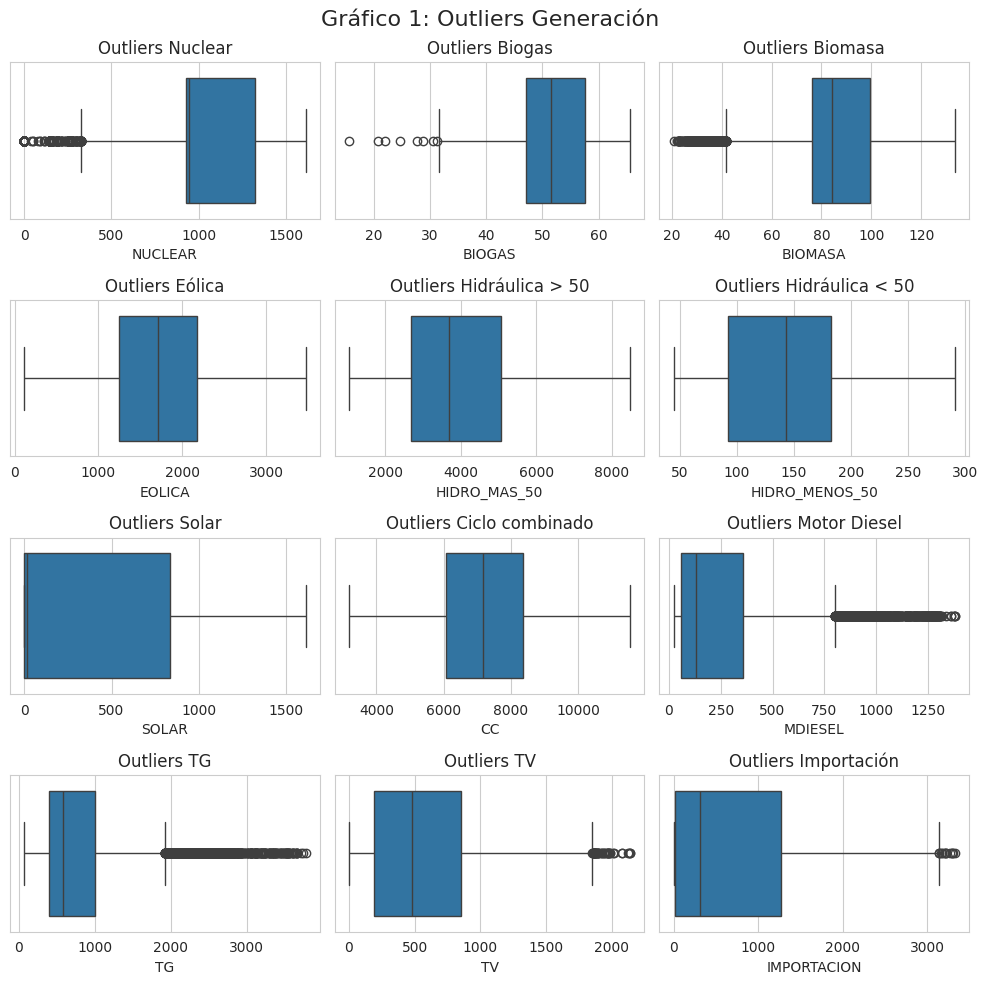

In [25]:
#Verificar outliers Generación - Boxplot y subplot
variables_generacion = ['NUCLEAR', 'BIOGAS', 'BIOMASA', 'EOLICA', 'HIDRO_MAS_50', 'HIDRO_MENOS_50', 'SOLAR', 'CC', 'MDIESEL', 'TG', 'TV', 'IMPORTACION']

# Se crea una figura con cuadrícula 4x3
fig, axes = plt.subplots(nrows=4, ncols=3, figsize=(10, 10)) # Axes[fila, columna], figsize(ancho, alto)

# Subplot 1
sns.boxplot(x=df_base['NUCLEAR'], ax=axes[0,0])
axes[0,0].set_title("Outliers Nuclear")

# Subplot 2
sns.boxplot(x=df_base['BIOGAS'], ax=axes[0,1])
axes[0,1].set_title("Outliers Biogas")

# Subplot 3
sns.boxplot(x=df_base['BIOMASA'], ax=axes[0,2])
axes[0,2].set_title("Outliers Biomasa")

# Subplot 4
sns.boxplot(x=df_base['EOLICA'], ax=axes[1,0])
axes[1,0].set_title("Outliers Eólica")

# Subplot 5
sns.boxplot(x=df_base['HIDRO_MAS_50'], ax=axes[1,1])
axes[1,1].set_title("Outliers Hidráulica > 50")

# Subplot 6
sns.boxplot(x=df_base['HIDRO_MENOS_50'], ax=axes[1,2])
axes[1,2].set_title("Outliers Hidráulica < 50")

# Subplot 7
sns.boxplot(x=df_base['SOLAR'], ax=axes[2,0])
axes[2,0].set_title("Outliers Solar")

# Subplot 8
sns.boxplot(x=df_base['CC'], ax=axes[2,1])
axes[2,1].set_title("Outliers Ciclo combinado")

# Subplot 9
sns.boxplot(x=df_base['MDIESEL'], ax=axes[2,2])
axes[2,2].set_title("Outliers Motor Diesel")


# Subplot 10
sns.boxplot(x=df_base['TG'], ax=axes[3,0])
axes[3,0].set_title("Outliers TG")

# Subplot 11
sns.boxplot(x=df_base['TV'], ax=axes[3,1])
axes[3,1].set_title("Outliers TV")

# Subplot 12
sns.boxplot(x=df_base['IMPORTACION'], ax=axes[3,2])
axes[3,2].set_title("Outliers Importación")

# Añadir título general
fig.suptitle('Gráfico 1: Outliers Generación ', fontsize=16)
plt.tight_layout()
plt.show()


Se puede observar en el gráfico 1 que las fuentes de generación que tienen outliers como por ejemplo importación, Motor diesel son las fuentes utilizadas para las horas pico de demanda, por lo cual van a tener valores altos en poco tiempo

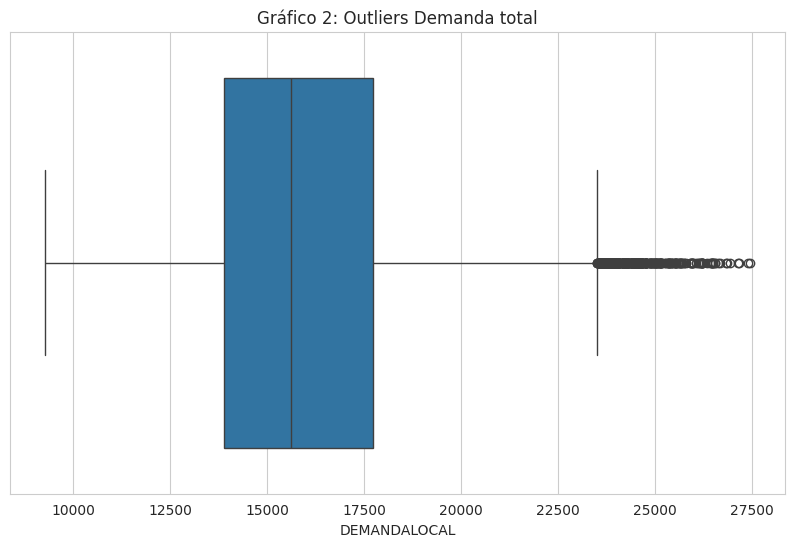

In [26]:
#Verificar outliers Demanda - Boxplot
plt.figure(figsize=(10, 6))
sns.boxplot(x=df_base['DEMANDALOCAL'])
plt.title('Gráfico 2: Outliers Demanda total')
plt.show()


Para la demanda se puede observar valores altos fuera de rango, por lo cual se presumen valores por pico de consumo.

## 6.2 Visualización de df_base

In [27]:
print(df_base.dtypes)  # Verificar el tipo de datos

AÑO                               int64
TIPODIA                          object
FECHA                    datetime64[ns]
HORA                              int64
NUCLEAR                         float64
BIOGAS                          float64
BIOMASA                         float64
EOLICA                          float64
HIDRO_MAS_50                    float64
HIDRO_MENOS_50                  float64
SOLAR                           float64
CC                              float64
MDIESEL                         float64
TG                              float64
TV                              float64
IMPORTACION                     float64
GENERACIONTOTAL                 float64
DEMANDALOCAL                    float64
GENERACIONTOTALSINIMP           float64
dtype: object


Al tener datos de varios años en df_base, se procede dividir los datos por categoria de fuente, a visualizar mediante barplot y visualizaciones interactivas

In [28]:
variables_generacion = ['NUCLEAR', 'BIOGAS', 'BIOMASA', 'EOLICA', 'HIDRO_MAS_50', 'HIDRO_MENOS_50', 'SOLAR', 'CC', 'MDIESEL', 'TG', 'TV', 'IMPORTACION']

In [29]:
variables_renovables= ['BIOGAS', 'BIOMASA', 'EOLICA', 'HIDRO_MAS_50', 'HIDRO_MENOS_50', 'SOLAR']

In [30]:
variables_termicas= ['NUCLEAR', 'CC', 'MDIESEL', 'TG', 'TV']

In [31]:
df_generacion = df_base.copy()
df_generacion = df_base[variables_generacion].sum()
df_generacion.head()

,0
NUCLEAR,2.688119e+07
BIOGAS,1.365232e+06
BIOMASA,2.248616e+06
EOLICA,4.480439e+07
HIDRO_MAS_50,1.029422e+08


In [32]:
df_renovables = df_base.copy()
df_renovables = df_base[variables_renovables].sum()
df_renovables.head()

,0
BIOGAS,1.365232e+06
BIOMASA,2.248616e+06
EOLICA,4.480439e+07
HIDRO_MAS_50,1.029422e+08
HIDRO_MENOS_50,3.755477e+06


In [33]:
df_termicas = df_base.copy()
df_termicas = df_base[variables_termicas].sum()
df_termicas.head()

,0
NUCLEAR,2.688119e+07
CC,1.896867e+08
MDIESEL,5.956376e+06
TG,2.000709e+07
TV,1.450901e+07


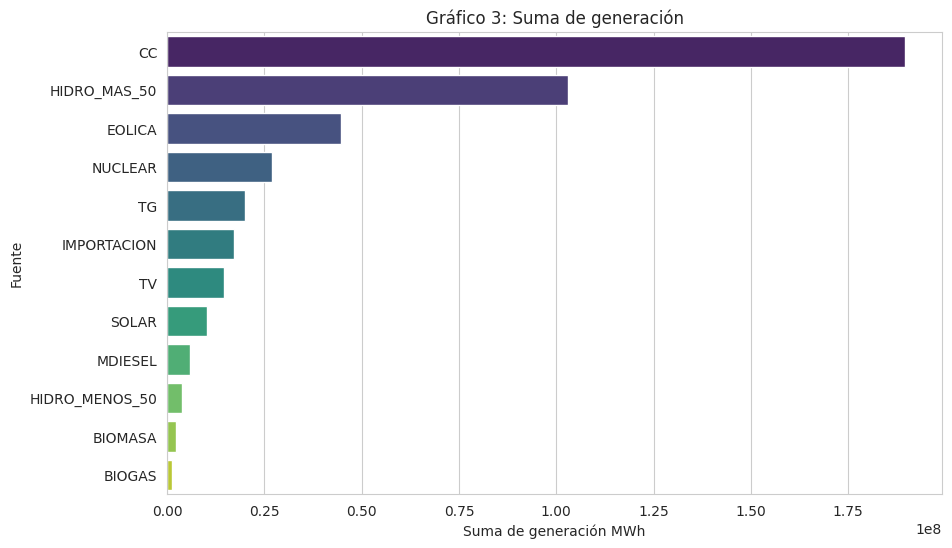

In [34]:
# Barplot: Suma de generación
plt.figure(figsize=(10, 6))
orden = df_generacion.sort_values(ascending=False).index
sns.barplot( x= df_generacion.values, y=df_generacion.index, ci='sd',order=orden, palette='viridis') # ci='sd' muestra desviación estándar
plt.title('Gráfico 3: Suma de generación')
plt.xlabel('Suma de generación MWh')
plt.ylabel('Fuente')
plt.show()

Se visualiza a lo largo del tiempo Ciclos Combinadoa con mayor generación acumulada

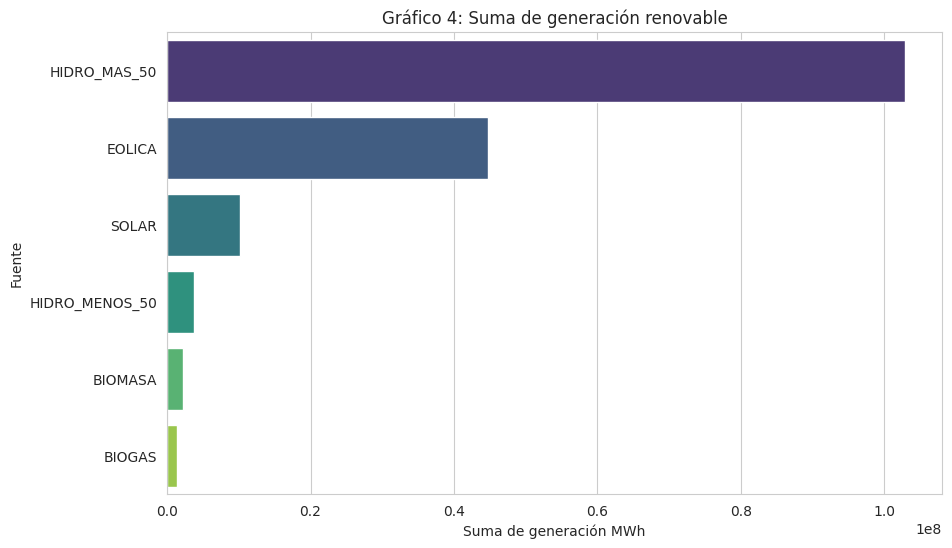

In [35]:
# Barplot: Suma de generación renovable
plt.figure(figsize=(10, 6))
orden = df_renovables.sort_values(ascending=False).index
sns.barplot( x= df_renovables.values, y=df_renovables.index, ci='sd',order=orden, palette='viridis') # ci='sd' muestra desviación estándar
plt.title('Gráfico 4: Suma de generación renovable')
plt.xlabel('Suma de generación MWh')
plt.ylabel('Fuente')
plt.show()

Se visualiza a lo largo del tiempo Hidroelectricas mayores a 50 MWh con mayor generación acumulada renovable

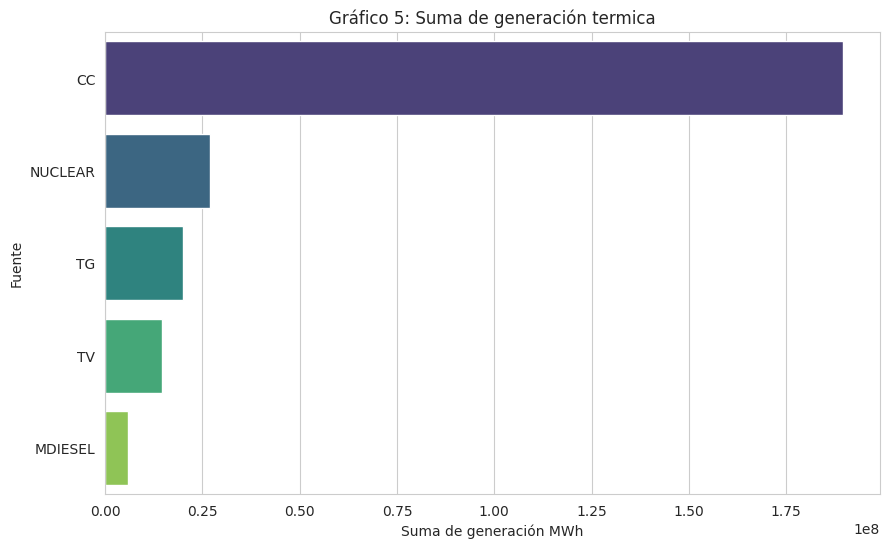

In [36]:
# Barplot: Suma de generación térmica
plt.figure(figsize=(10, 6))
orden = df_termicas.sort_values(ascending=False).index
sns.barplot( x= df_termicas.values, y=df_termicas.index, ci='sd',order=orden, palette='viridis') # ci='sd' muestra desviación estándar
plt.title('Gráfico 5: Suma de generación termica')
plt.xlabel('Suma de generación MWh')
plt.ylabel('Fuente')
plt.show()

Se visualiza a lo largo del tiempo Ciclos combinados con mayor generación acumulada térmica

In [37]:
fig = go.Figure() # Se crea figura

 #generacion vs importación vs demanda

fig.add_trace(go.Scatter(x=df_base['FECHA'], y=df_base['GENERACIONTOTALSINIMP'], mode='lines', name='GENERACION', line=dict(color='red')))
fig.add_trace(go.Scatter(x=df_base['FECHA'], y=df_base['DEMANDALOCAL'], mode='lines', name='DEMANDALOCAL', line=dict(color='blue')))
fig.add_trace(go.Scatter(x=df_base['FECHA'], y=df_base['IMPORTACION'], mode='lines', name='IMPORTACION', line=dict(color='green')))

# Colorear fondo para 2022
fig.add_vrect(
    x0="2022-01-01", x1="2022-12-31",
    fillcolor="lightblue", opacity=0.3,
    layer="below", line_width=0,
    annotation_text="2022", annotation_position="top left"
)

# Colorear fondo para 2023
fig.add_vrect(
    x0="2023-01-01", x1="2023-12-31",
    fillcolor="lightgreen", opacity=0.3,
    layer="below", line_width=0,
    annotation_text="2023", annotation_position="top left"
)

# Colorear fondo para 2024
fig.add_vrect(
    x0="2024-01-01", x1="2024-12-31",
    fillcolor="lightpink", opacity=0.3,
    layer="below", line_width=0,
    annotation_text="2024", annotation_position="top left"
)

#Diseño

fig.update_layout(
    title='Gráfico 6: generación, demanda, importación vs fecha ',
    xaxis_title='fecha',
    yaxis_title='MWh',
    hovermode='x unified',
    template='plotly_white'
)

fig.show()

En el gráfico 6 se puede visualizar la dependencia de importación generación y demanda respecto a la estacionalidad.
A mayor demanda mayor importación

## 6.3 Visualización de variables

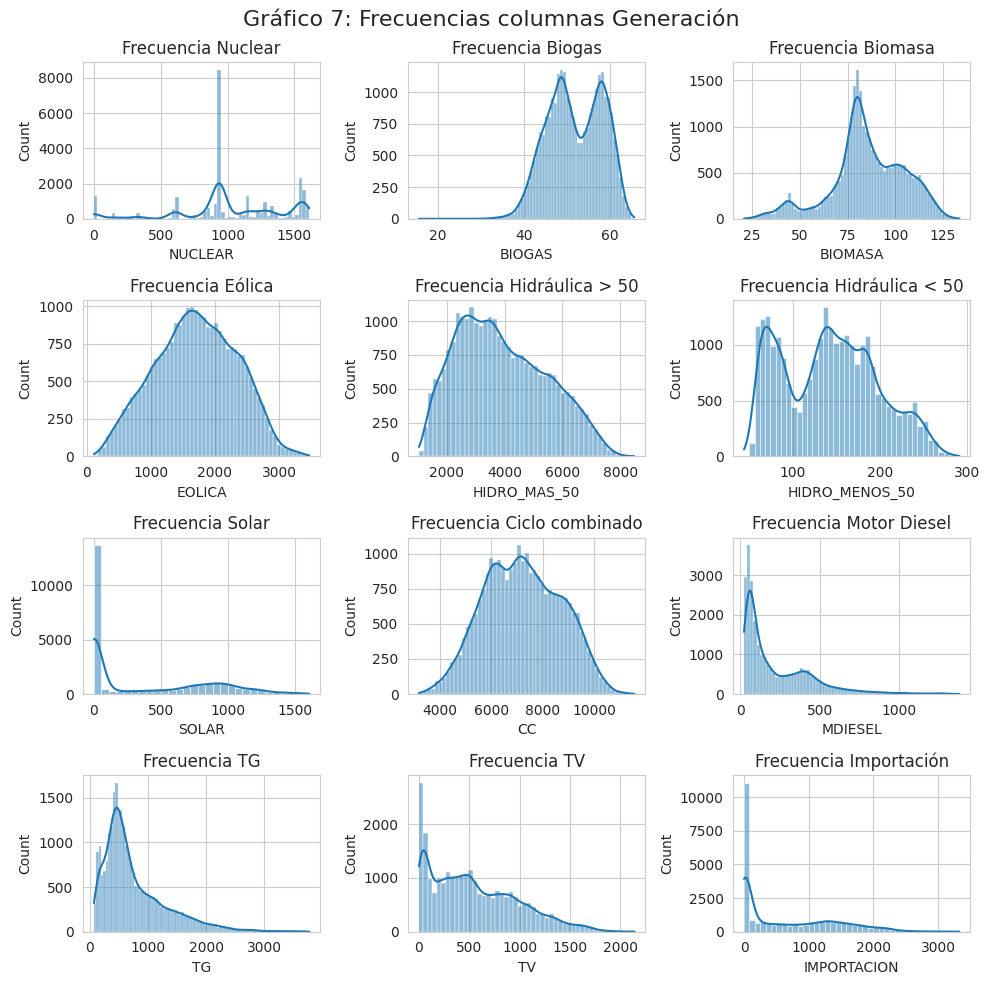

In [38]:
#Verificar distribución de Generación - Hisplot y subplot
# Se crea una figura con cuadrícula 4x3
fig, axes = plt.subplots(nrows=4, ncols=3, figsize=(10, 10)) # Axes[fila, columna], figsize(ancho, alto)

# Subplot 1
sns.histplot(df_base['NUCLEAR'], kde=True, ax=axes[0,0])
axes[0,0].set_title("Frecuencia Nuclear")
# Subplot 2
sns.histplot(df_base['BIOGAS'], kde=True, ax=axes[0,1])
axes[0,1].set_title("Frecuencia Biogas")
# Subplot 3
sns.histplot(df_base['BIOMASA'], kde=True, ax=axes[0,2])
axes[0,2].set_title("Frecuencia Biomasa")
# Subplot 4
sns.histplot(df_base['EOLICA'], kde=True, ax=axes[1,0])
axes[1,0].set_title("Frecuencia Eólica")
# Subplot 5
sns.histplot(df_base['HIDRO_MAS_50'], kde=True, ax=axes[1,1])
axes[1,1].set_title("Frecuencia Hidráulica > 50")
# Subplot 6
sns.histplot(df_base['HIDRO_MENOS_50'], kde=True, ax=axes[1,2])
axes[1,2].set_title("Frecuencia Hidráulica < 50")
# Subplot 7
sns.histplot(df_base['SOLAR'], kde=True, ax=axes[2,0])
axes[2,0].set_title("Frecuencia Solar")
# Subplot 8
sns.histplot(df_base['CC'], kde=True, ax=axes[2,1])
axes[2,1].set_title("Frecuencia Ciclo combinado")
# Subplot 9
sns.histplot(df_base['MDIESEL'], kde=True, ax=axes[2,2])
axes[2,2].set_title("Frecuencia Motor Diesel")
# Subplot 10
sns.histplot(df_base['TG'], kde=True, ax=axes[3,0])
axes[3,0].set_title("Frecuencia TG")
# Subplot 11
sns.histplot(df_base['TV'], kde=True, ax=axes[3,1])
axes[3,1].set_title("Frecuencia TV")
# Subplot 12
sns.histplot(df_base['IMPORTACION'], kde=True, ax=axes[3,2])
axes[3,2].set_title("Frecuencia Importación")

# Añadir título general
fig.suptitle('Gráfico 7: Frecuencias columnas Generación ', fontsize=16)
plt.tight_layout()
plt.show()


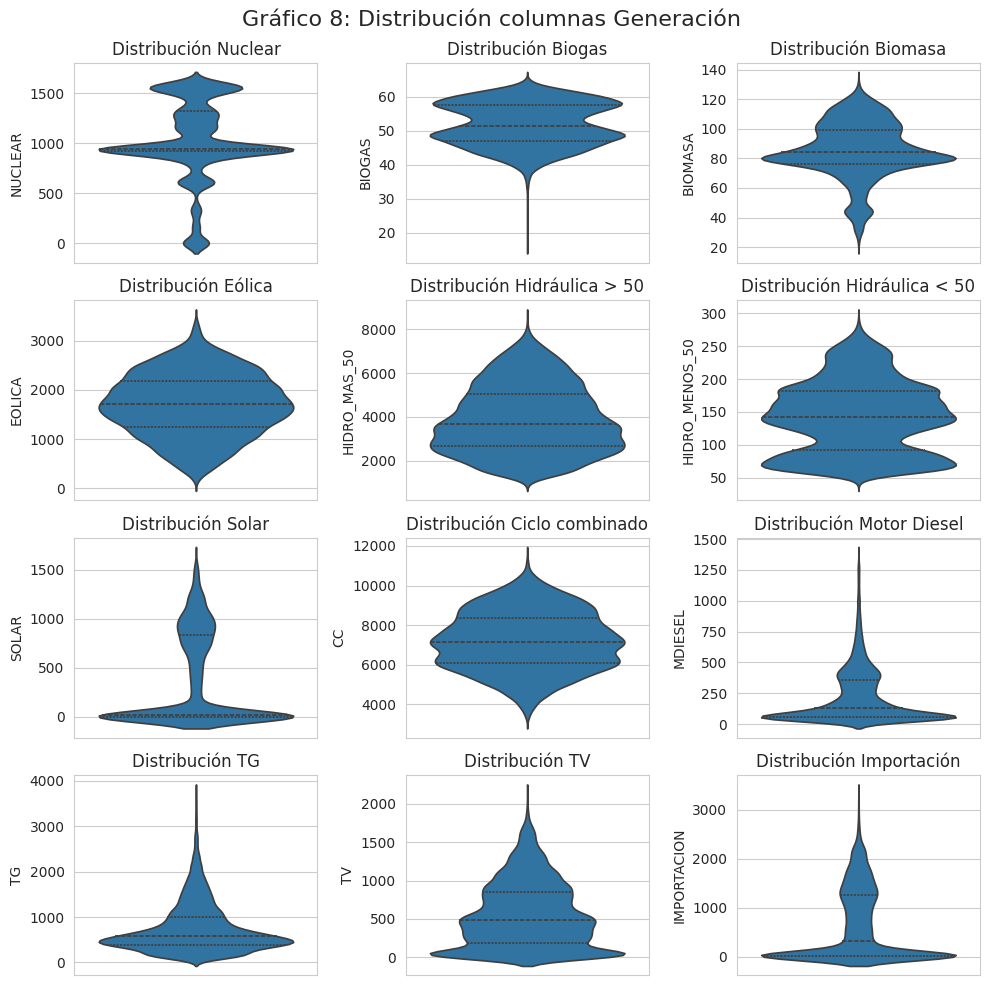

In [39]:
#Verificar distribución de Generación - Violinplot y subplot
# Se crea una figura con cuadrícula 4x3
fig, axes = plt.subplots(nrows=4, ncols=3, figsize=(10, 10)) # Axes[fila, columna], figsize(ancho, alto)

# Subplot 1
sns.violinplot(df_base['NUCLEAR'], ax=axes[0,0], inner='quartile') # inner='quartile' muestra los cuartiles dentro
axes[0,0].set_title("Distribución Nuclear")
# Subplot 2
sns.violinplot(df_base['BIOGAS'], ax=axes[0,1], inner='quartile')
axes[0,1].set_title("Distribución Biogas")
# Subplot 3
sns.violinplot(df_base['BIOMASA'], ax=axes[0,2], inner='quartile')
axes[0,2].set_title("Distribución Biomasa")
# Subplot 4
sns.violinplot(df_base['EOLICA'], ax=axes[1,0], inner='quartile')
axes[1,0].set_title("Distribución Eólica")
# Subplot 5
sns.violinplot(df_base['HIDRO_MAS_50'], ax=axes[1,1], inner='quartile')
axes[1,1].set_title("Distribución Hidráulica > 50")
# Subplot 6
sns.violinplot(df_base['HIDRO_MENOS_50'], ax=axes[1,2], inner='quartile')
axes[1,2].set_title("Distribución Hidráulica < 50")
# Subplot 7
sns.violinplot(df_base['SOLAR'], ax=axes[2,0], inner='quartile')
axes[2,0].set_title("Distribución Solar")
# Subplot 8
sns.violinplot(df_base['CC'], ax=axes[2,1], inner='quartile')
axes[2,1].set_title("Distribución Ciclo combinado")
# Subplot 9
sns.violinplot(df_base['MDIESEL'], ax=axes[2,2], inner='quartile')
axes[2,2].set_title("Distribución Motor Diesel")
# Subplot 10
sns.violinplot(df_base['TG'], ax=axes[3,0], inner='quartile')
axes[3,0].set_title("Distribución TG")
# Subplot 11
sns.violinplot(df_base['TV'], ax=axes[3,1], inner='quartile')
axes[3,1].set_title("Distribución TV")
# Subplot 12
sns.violinplot(df_base['IMPORTACION'], ax=axes[3,2], inner='quartile')
axes[3,2].set_title("Distribución Importación")

# Añadir título general
fig.suptitle('Gráfico 8: Distribución columnas Generación ', fontsize=16)
plt.tight_layout()
plt.show()




### 6.3.1 Generacion y Demanda total

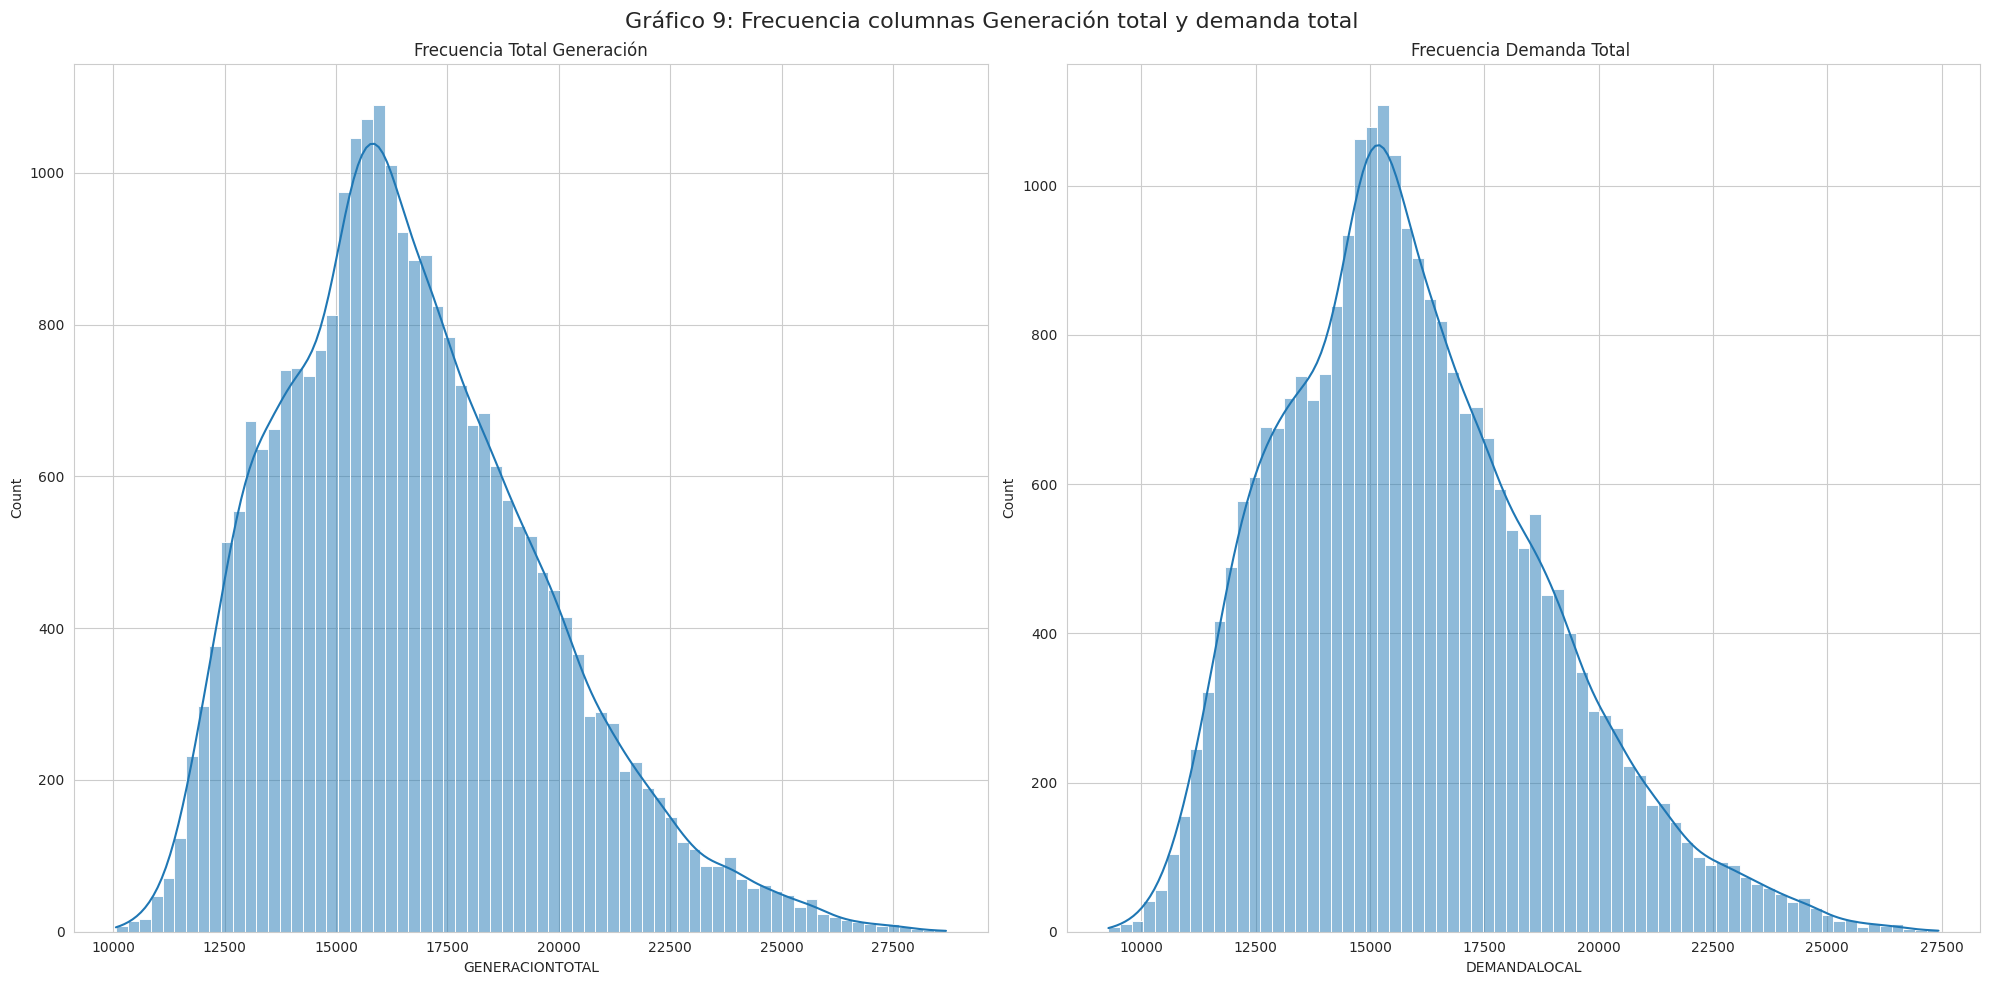

In [40]:
#Verificar Frecuencia de Generación y Demanda- Hisplot y subplot
# Se crea una figura con cuadrícula 2x2
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(20, 10)) # Axes[fila, columna], figsize(ancho, alto)

# Subplot 1
sns.histplot(df_base['GENERACIONTOTAL'], kde=True, ax=axes[0])
axes[0].set_title("Frecuencia Total Generación")
# Subplot 2
sns.histplot(df_base['DEMANDALOCAL'], kde=True, ax=axes[1])
axes[1].set_title("Frecuencia Demanda Total ")

# Añadir título general
fig.suptitle('Gráfico 9: Frecuencia columnas Generación total y demanda total ', fontsize=16)
plt.tight_layout()
plt.show()



Se verifica que la distribución de las variables generación y demanda total tienen asimetria positiva, teniendo algunos valores pico y la mayoria en valores mas bajos que los picos. También se observa que coinciden en su distribución.

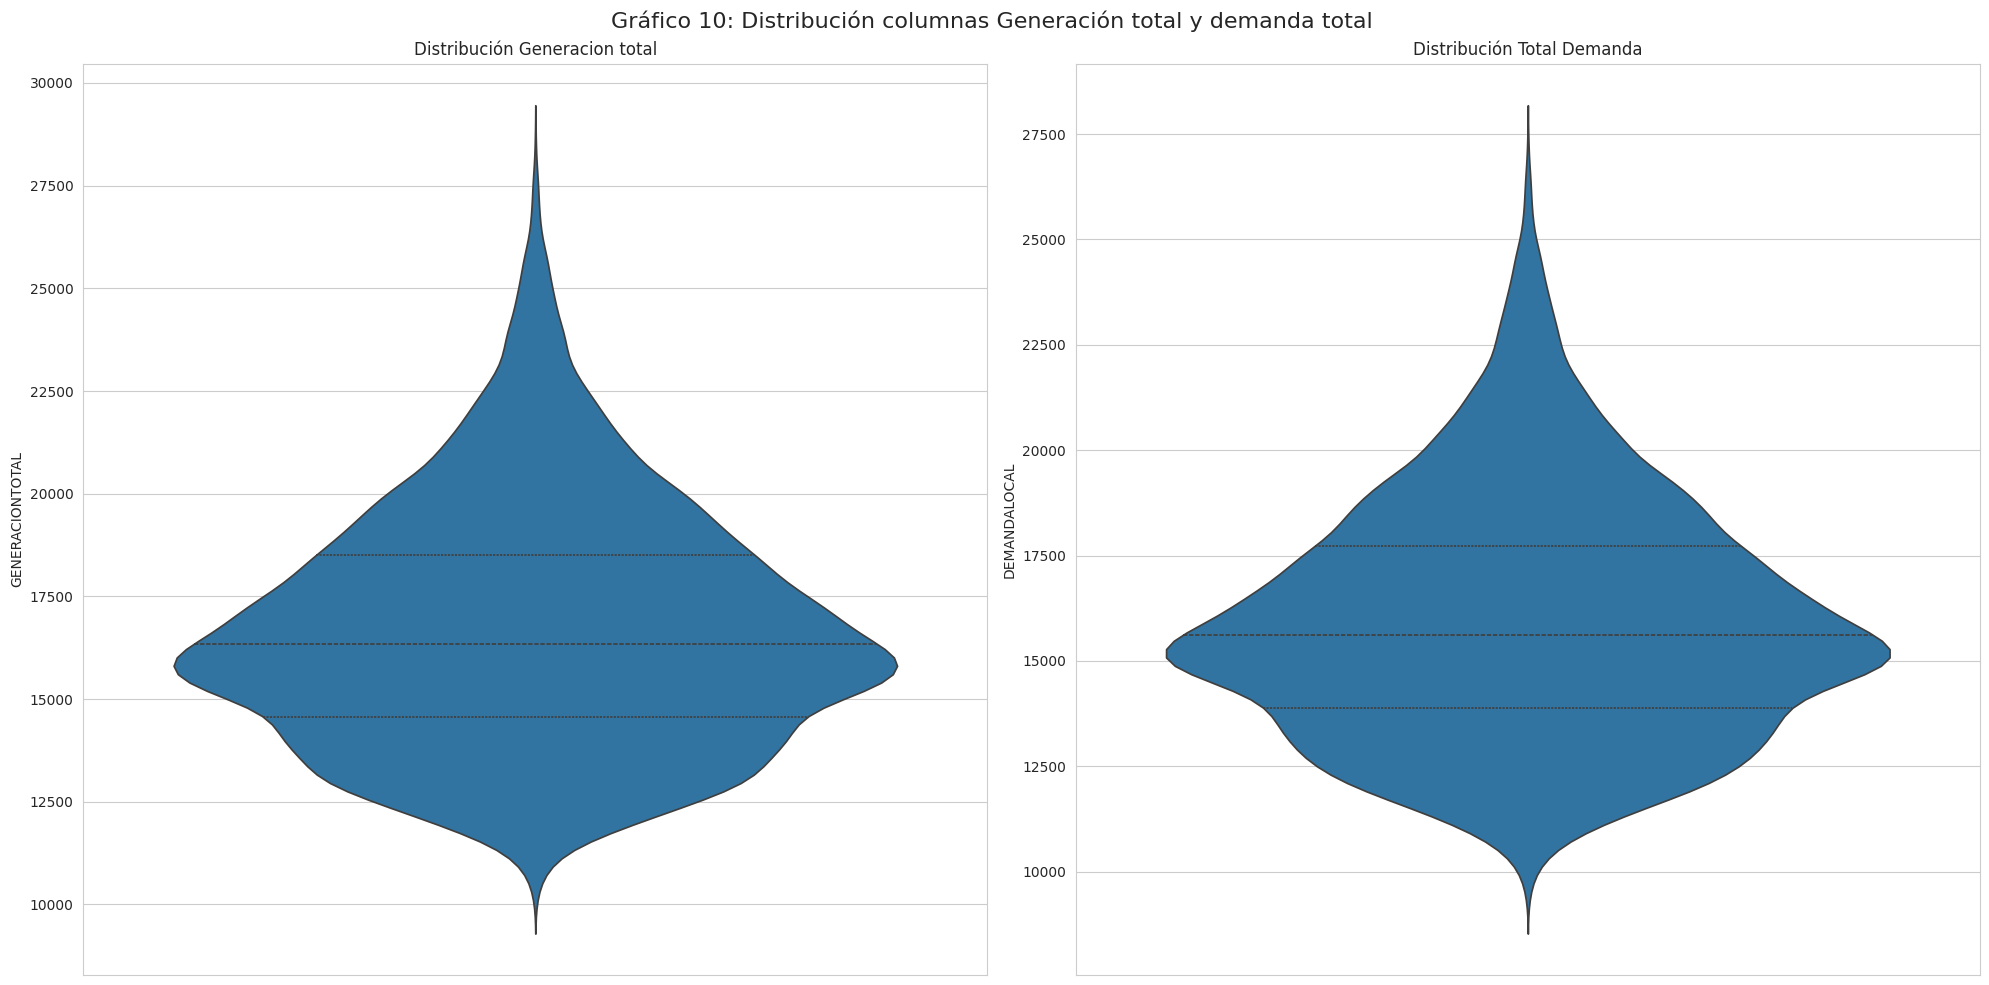

In [41]:
#Verificar distribución de Generación y demanda - Violinplot y subplot
# Se crea una figura con cuadrícula 1x2
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(20, 10)) # Axes[fila, columna], figsize(ancho, alto)

# Subplot 1
sns.violinplot(df_base['GENERACIONTOTAL'], ax=axes[0], inner='quartile') # inner='quartile' muestra los cuartiles dentro
axes[0].set_title("Distribución Generacion total")
# Subplot 2
sns.violinplot(df_base['DEMANDALOCAL'], ax=axes[1], inner='quartile')
axes[1].set_title("Distribución Total Demanda")

# Añadir título general
fig.suptitle('Gráfico 10: Distribución columnas Generación total y demanda total ', fontsize=16)
plt.tight_layout()
plt.show()



En el gráfico 10 se observa que la distribución de la generación total y la demanda total es similar siendo la media de generación un poco mayor

In [42]:
print("Media Generacion Total:" , df_base['GENERACIONTOTAL'].mean())
print("Media Demanda Total:" , df_base['DEMANDALOCAL'].mean())

Media Generacion Total: 16708.096895567218
Media Demanda Total: 15962.522354014598


In [43]:
print("Mediana Generacion Total:" , df_base['GENERACIONTOTAL'].median())
print("Mediana Demanda Total:" , df_base['DEMANDALOCAL'].median())

Mediana Generacion Total: 16342.899000000001
Mediana Demanda Total: 15617.5


### 6.3.2 Importacion

In [44]:
asimetria_df_base = df_base['IMPORTACION'].skew()
curtosis_df_base = df_base['IMPORTACION'].kurt() #grado de apuntamiento o achatamiento de la distribución de frecuencia.
print("Asimetría:")
print(asimetria_df_base)
print("\nCurtosis:")
print(curtosis_df_base)

Asimetría:
0.7860233449709062

Curtosis:
-0.6139149576739742


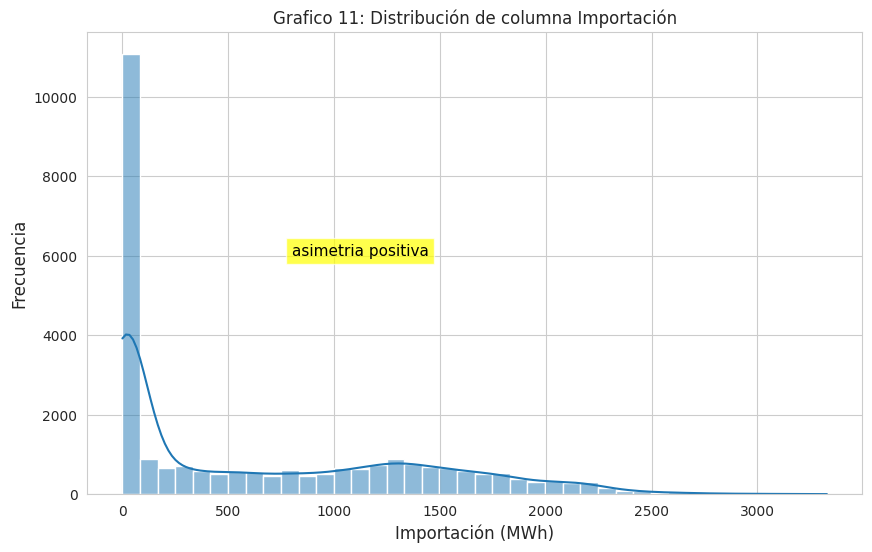

In [45]:
sns.histplot(df_base['IMPORTACION'], kde=True)
plt.title('Grafico 11: Distribución de columna Importación')
plt.xlabel("Importación (MWh)", fontsize=12)
plt.ylabel("Frecuencia", fontsize=12)

# Insight anotado
plt.text(800,6000, "asimetria positiva",
         fontsize=11, color="black", bbox=dict(facecolor="yellow", alpha=0.7))
plt.show()

Se verifica que la distribución de la variable Importación tiene asimetria positiva, la mayoria de los valores estan concentrados en muy pocos MWh, esto indica que la importación de energía es excepcional en algunos casos con valores altos

##6.4 Correlaciones entre variables

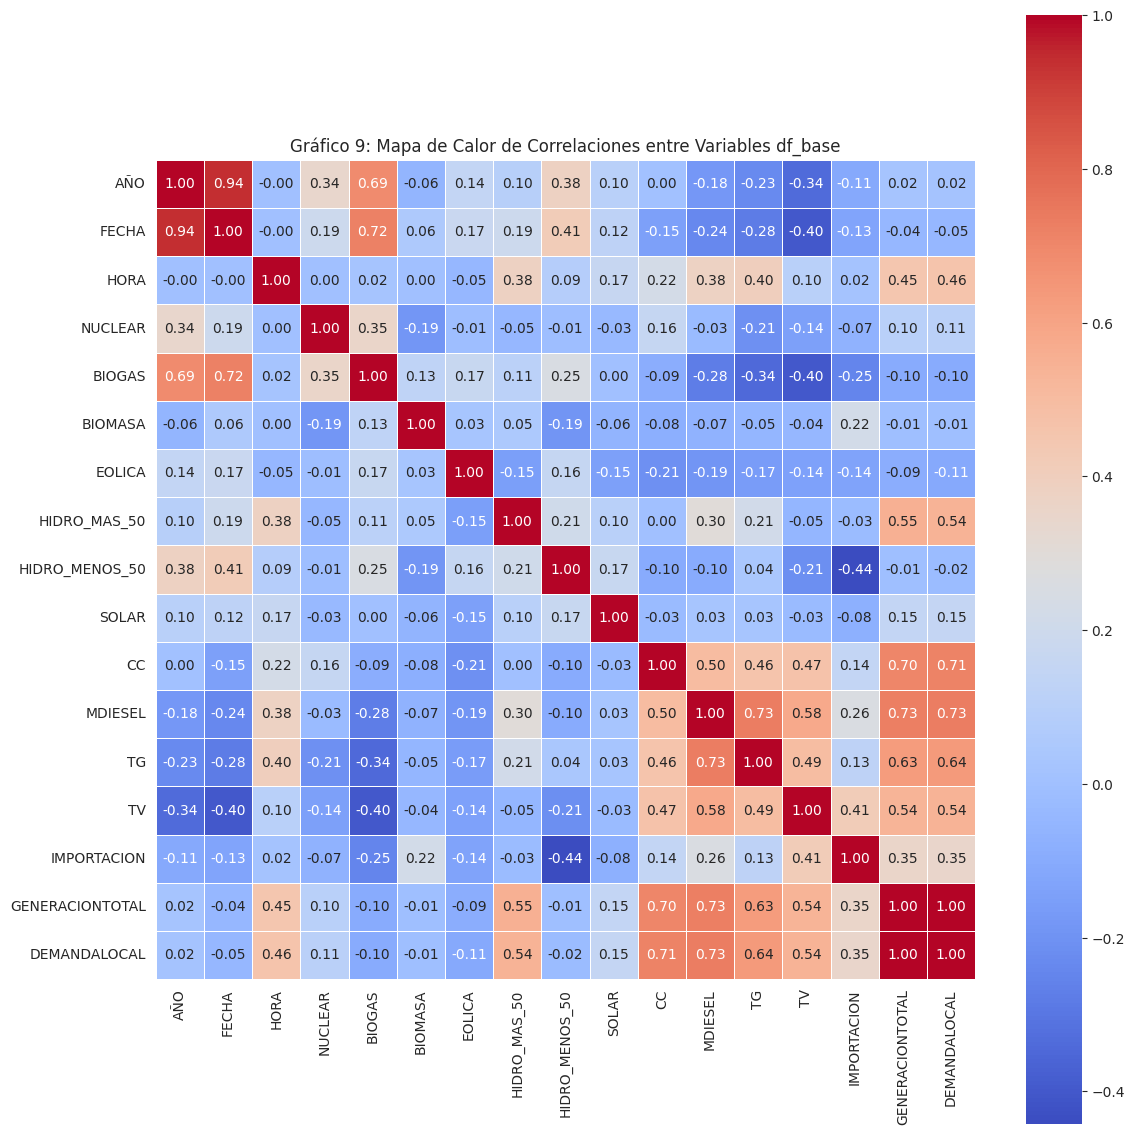

In [46]:
# Matriz de correlación-heatmap de seaborn
variables_numericas = ['AÑO','FECHA','HORA','NUCLEAR', 'BIOGAS', 'BIOMASA', 'EOLICA', 'HIDRO_MAS_50', 'HIDRO_MENOS_50', 'SOLAR', 'CC', 'MDIESEL', 'TG', 'TV', 'IMPORTACION', 'GENERACIONTOTAL', 'DEMANDALOCAL']
correlaciones = df_base[variables_numericas].corr()
# Crear el heatmap
plt.figure(figsize=(12, 12)) #Tamaño de gráfico
sns.heatmap(correlaciones,
            cbar = True,
            square = True,
            annot=True,
            fmt= '.2f',
            annot_kws={'size': 10},
            cmap= 'coolwarm',
            linewidths=0.5)
plt.title('Gráfico 9: Mapa de Calor de Correlaciones entre Variables df_base')
plt.tight_layout()
plt.show()

En el grafico 9 se puede observar los valores en rojo con correlacion positiva , es decir, si una variable aumenta la otra tambien aumenta.
 Por ejemplo generación y demanda total, año y fecha.
Para Ciclos combinados(CC) y Motor diesel la correlacion es positiva respecto a la demanda y generación, por lo cual se puede inferir que al aumentar la demanda aumenta la generacion de esas fuentes.

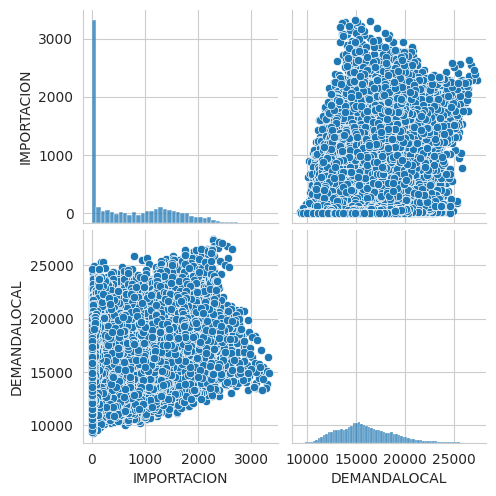

In [47]:
#Grafico con pairplot
sns.pairplot(df_base[['IMPORTACION', 'DEMANDALOCAL']])
plt.show()

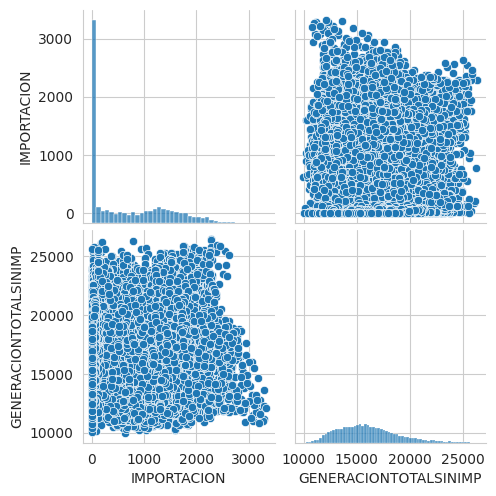

In [48]:
#Grafico con pairplot
sns.pairplot(df_base[['IMPORTACION','GENERACIONTOTALSINIMP']])
plt.show()


En los gráficos anteriores se observa una correlación positiva entre la demanda, generación y las importaciones, el crecimiento de estas conlleva el incremento de las importaciones.

En importación la mayoria de los valores estan concentrados en muy pocos MWh, indica que la importación de energía es excepcional en algunos casos con valores altos.


## 6.5 Visualización de un año (df_2024)

Para poder entender con mayor calridad la estacionalidad de la demanda, se filtra el df_base para 2024

In [49]:
df_base

,AÑO,TIPODIA,FECHA,HORA,NUCLEAR,BIOGAS,BIOMASA,EOLICA,HIDRO_MAS_50,HIDRO_MENOS_50,SOLAR,CC,MDIESEL,TG,TV,IMPORTACION,GENERACIONTOTAL,DEMANDALOCAL,GENERACIONTOTALSINIMP
FECHATOTAL,,,,,,,,,,,,,,,,,,,
01/01/2022 1:00:00,2022,No Hábil,2022-01-01,1,1357.060,48.098,67.429,1649.507,1678.081,110.497,0.000,8884.915,264.439,1215.024,1100.361,278.204,16653.615,15894.0,16375.411
01/01/2022 2:00:00,2022,No Hábil,2022-01-01,2,1360.842,47.729,50.870,1529.287,1744.359,111.797,0.000,9269.344,238.832,1123.293,1100.440,232.120,16808.913,15967.0,16576.793
01/01/2022 3:00:00,2022,No Hábil,2022-01-01,3,1359.371,47.745,45.193,1490.881,1570.168,110.453,0.000,9711.728,237.449,1113.151,1091.554,222.778,17000.471,16246.0,16777.693
01/01/2022 4:00:00,2022,No Hábil,2022-01-01,4,1357.517,46.755,45.664,1848.192,1558.943,110.664,0.000,9598.543,235.638,1120.335,1089.965,276.418,17288.634,16315.0,17012.216
01/01/2022 5:00:00,2022,No Hábil,2022-01-01,5,1358.948,46.883,46.031,2270.724,1574.759,111.008,0.000,9040.523,238.270,1044.805,1093.251,291.968,17117.170,16105.0,16825.202
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
31/12/2024 20:00:00,2024,Hábil,2024-12-31,20,1139.181,54.986,86.832,2259.766,4226.993,153.553,288.373,8792.182,172.199,761.922,373.344,0.028,18309.359,17575.0,18309.331
31/12/2024 21:00:00,2024,Hábil,2024-12-31,21,1139.984,55.428,82.761,2255.846,4528.189,170.953,20.168,8982.498,176.392,899.281,322.530,0.028,18634.058,17881.0,18634.030
31/12/2024 22:00:00,2024,Hábil,2024-12-31,22,1140.962,55.535,83.628,1972.647,4107.739,165.030,0.000,9045.500,181.909,883.725,312.528,0.022,17949.225,17374.0,17949.203


In [50]:
#Se filtra df_base para 2024
df_2024=df_base.copy()
df_2024 = df_base[df_base['AÑO'] == 2024]

df_2024.shape #tamaño de dataframe

(8784, 19)

In [51]:
df_2024

,AÑO,TIPODIA,FECHA,HORA,NUCLEAR,BIOGAS,BIOMASA,EOLICA,HIDRO_MAS_50,HIDRO_MENOS_50,SOLAR,CC,MDIESEL,TG,TV,IMPORTACION,GENERACIONTOTAL,DEMANDALOCAL,GENERACIONTOTALSINIMP
FECHATOTAL,,,,,,,,,,,,,,,,,,,
01/01/2024 1:00:00,2024,No Hábil,2024-01-01,1,1553.168,51.827,37.379,1315.148,4665.665,139.757,0.000,5260.473,44.804,203.033,8.860,12.672,13292.786,12781.0,13280.114
01/01/2024 2:00:00,2024,No Hábil,2024-01-01,2,1552.417,50.786,37.878,1233.373,4816.610,137.700,0.000,5180.658,42.485,146.784,8.985,12.594,13220.270,12725.0,13207.676
01/01/2024 3:00:00,2024,No Hábil,2024-01-01,3,1552.489,50.649,37.791,1320.279,4695.603,137.704,0.000,5215.749,42.366,146.440,8.931,12.237,13220.238,12660.0,13208.001
01/01/2024 4:00:00,2024,No Hábil,2024-01-01,4,1552.198,49.140,37.892,1071.560,4842.162,137.792,0.000,5231.905,42.999,148.208,8.951,11.810,13134.617,12433.0,13122.807
01/01/2024 5:00:00,2024,No Hábil,2024-01-01,5,1553.620,49.278,37.684,974.324,4823.720,137.875,0.000,5237.212,39.124,151.899,8.920,11.414,13025.070,12201.0,13013.656
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
31/12/2024 20:00:00,2024,Hábil,2024-12-31,20,1139.181,54.986,86.832,2259.766,4226.993,153.553,288.373,8792.182,172.199,761.922,373.344,0.028,18309.359,17575.0,18309.331
31/12/2024 21:00:00,2024,Hábil,2024-12-31,21,1139.984,55.428,82.761,2255.846,4528.189,170.953,20.168,8982.498,176.392,899.281,322.530,0.028,18634.058,17881.0,18634.030
31/12/2024 22:00:00,2024,Hábil,2024-12-31,22,1140.962,55.535,83.628,1972.647,4107.739,165.030,0.000,9045.500,181.909,883.725,312.528,0.022,17949.225,17374.0,17949.203


In [52]:
fig = go.Figure() # Se crea figura

#Fuentes Generacion total vs demanda total

fig.add_trace(go.Scatter(x=df_2024.index , y=df_2024['GENERACIONTOTALSINIMP'],mode='lines', name='GENERACION', line=dict(color='red')))
fig.add_trace(go.Scatter(x=df_2024.index , y=df_2024['DEMANDALOCAL'],  mode='lines', name='DEMANDALOCAL', line=dict(color='blue')))
fig.add_trace(go.Scatter(x=df_2024.index , y=df_2024['IMPORTACION'], mode='lines', name='IMPORTACION', line=dict(color='green')))

#Diseño

fig.update_layout(
    title='Gráfico 10: Generación, demanda vs importación para 2024 ',
    xaxis_title='Fecha',
    yaxis_title='MWh',
    hovermode='x unified',
    template='plotly_white'
)

fig.show()




Se puede observar en el gráfico 10 que la generación (sin tener en cuenta importación) en algunos meses es menor que la demanda.
También se refleja estacionalidad con picos de consumo en verano (Enero, Febrero). Con respecto a la importación se observa aumento estacional en verano e invierno

## 6.6 Visualización de un dia (df_2024_1_31)

Para poder comprender con mayor calridad el despacho de energía y como cubre la demanda el df_2024 para un dia de verano 31/1/2024

In [53]:
df_2024_1_31=df_2024.copy()
df_2024_1_31 = df_2024[df_2024['FECHA'] == '2024-01-31']
df_2024_1_31

,AÑO,TIPODIA,FECHA,HORA,NUCLEAR,BIOGAS,BIOMASA,EOLICA,HIDRO_MAS_50,HIDRO_MENOS_50,SOLAR,CC,MDIESEL,TG,TV,IMPORTACION,GENERACIONTOTAL,DEMANDALOCAL,GENERACIONTOTALSINIMP
FECHATOTAL,,,,,,,,,,,,,,,,,,,
31/01/2024 1:00:00,2024,Hábil,2024-01-31,1,1221.644,52.029,79.587,1710.980,5701.061,213.284,0.000,9978.822,338.289,870.304,982.246,1397.076,22545.322,21752.0,21148.246
31/01/2024 2:00:00,2024,Hábil,2024-01-31,2,1222.891,51.970,78.678,1837.797,5047.260,206.911,0.000,9988.368,360.662,781.961,935.040,729.417,21240.955,20564.0,20511.538
31/01/2024 3:00:00,2024,Hábil,2024-01-31,3,1223.073,52.643,78.460,1817.370,4763.422,204.606,0.000,10016.811,231.665,760.190,912.654,226.881,20287.775,19628.0,20060.894
31/01/2024 4:00:00,2024,Hábil,2024-01-31,4,1222.742,52.427,77.655,1967.187,4508.529,204.575,0.000,9677.133,85.425,727.070,890.519,354.924,19768.186,18929.0,19413.262
31/01/2024 5:00:00,2024,Hábil,2024-01-31,5,1223.454,52.678,78.510,1958.107,4070.555,205.220,0.000,9679.386,59.289,596.998,888.283,447.092,19259.572,18402.0,18812.480
31/01/2024 6:00:00,2024,Hábil,2024-01-31,6,1223.482,52.584,78.145,2018.351,4016.909,200.447,0.000,9707.682,36.818,339.896,887.004,503.691,19065.009,18019.0,18561.318
31/01/2024 7:00:00,2024,Hábil,2024-01-31,7,1225.691,52.692,74.358,1862.691,4016.593,200.790,0.001,9395.036,37.484,334.410,881.300,516.731,18597.777,17666.0,18081.046
31/01/2024 8:00:00,2024,Hábil,2024-01-31,8,1226.575,50.520,75.394,1652.230,4418.330,208.775,102.198,9313.879,41.139,410.414,884.596,343.648,18727.698,17841.0,18384.050
31/01/2024 9:00:00,2024,Hábil,2024-01-31,9,1227.047,51.201,75.965,1544.046,4703.968,209.584,741.824,9224.327,52.219,619.075,884.998,834.540,20168.794,19305.0,19334.254


In [54]:
fig = go.Figure() # Se crea figura

#Fuentes de generación

fig.add_trace(go.Scatter(x=df_2024_1_31['HORA'], y=df_2024_1_31['NUCLEAR'], mode='lines', name='NUCLEAR'))
fig.add_trace(go.Scatter(x=df_2024_1_31['HORA'], y=df_2024_1_31['BIOGAS'], mode='lines', name='BIOGAS'))
fig.add_trace(go.Scatter(x=df_2024_1_31['HORA'], y=df_2024_1_31['BIOMASA'], mode='lines', name='BIOMASA'))
fig.add_trace(go.Scatter(x=df_2024_1_31['HORA'], y=df_2024_1_31['EOLICA'], mode='lines', name='EOLICA'))
fig.add_trace(go.Scatter(x=df_2024_1_31['HORA'], y=df_2024_1_31['HIDRO_MAS_50'], mode='lines', name='HIDRO_MAS_50'))
fig.add_trace(go.Scatter(x=df_2024_1_31['HORA'], y=df_2024_1_31['HIDRO_MENOS_50'], mode='lines', name='HIDRO_MENOS_50'))
fig.add_trace(go.Scatter(x=df_2024_1_31['HORA'], y=df_2024_1_31['SOLAR'], mode='lines', name='SOLAR'))
fig.add_trace(go.Scatter(x=df_2024_1_31['HORA'], y=df_2024_1_31['CC'], mode='lines', name='CC'))
fig.add_trace(go.Scatter(x=df_2024_1_31['HORA'], y=df_2024_1_31['MDIESEL'], mode='lines', name='MDIESEL'))
fig.add_trace(go.Scatter(x=df_2024_1_31['HORA'], y=df_2024_1_31['TG'], mode='lines', name='TG'))
fig.add_trace(go.Scatter(x=df_2024_1_31['HORA'], y=df_2024_1_31['TV'], mode='lines', name='TV'))
fig.add_trace(go.Scatter(x=df_2024_1_31['HORA'], y=df_2024_1_31['IMPORTACION'], mode='lines+markers', line=dict(color='grey', width=2),marker=dict(color='grey', size=6), name='IMPORTACION'))

#Demanda total
fig.add_trace(go.Scatter(x=df_2024_1_31['HORA'], y=df_2024_1_31['DEMANDALOCAL'], mode='lines+markers', line=dict(color='black', width=2),marker=dict(color='black', size=6), name='DEMANDALOCAL'))

#Diseño

fig.update_layout(
    title='Gráfico 11: Evolución de las fuentes de generación para 31/1/2024 por hora vs demanda',
    xaxis_title='Hora',
    yaxis_title='MWh',
    hovermode='x unified',
    template='plotly_white'
)

fig.show()


En el gráfico 11 se puede observar que la fuente Ciclos combinados es la fuente con mayor generación seguida por la generación hidraulica de base la cual se debe despachar y la nuclear donde se observa que es continua en el tiempo. El grafico tambien indica que no todas las fuentes son de generación continua, depende de su disponibilidad.

## 6.7 Visualización Demanda vs Oferta para un dia

In [55]:
fig = go.Figure() # Se crea figura

#Fuentes Generacion total vs demanda total

fig.add_trace(go.Scatter(x=df_2024_1_31['HORA'], y=df_2024_1_31['GENERACIONTOTAL'], mode='lines', name='GENERACIONTOTAL', line=dict(color='red')))
fig.add_trace(go.Scatter(x=df_2024['HORA'], y=df_2024_1_31['DEMANDALOCAL'], mode='lines', name='DEMANDALOCAL', line=dict(color='blue')))


#Diseño

fig.update_layout(
    title='Gráfico 12: Generación total vs demanda total para 31/1/2024 ',
    xaxis_title='hora',
    yaxis_title='MWh',
    hovermode='x unified',
    template='plotly_white'
)

fig.show()

En el grafico 12 se puede visualizar una curva tipica horaria de verano con el pico de demanda y generación de 14 a 18 h. Tambien se visualiza que para este dia la curva de generacion cubre la demanda total.

## 6.8 Visualización Fuentes para un dia

In [56]:
# Se crea grafico de barras superpuestas por fuente con px.bar
fig = go.Figure() # Se crea figura
fig = px.bar(df_2024_1_31, x='HORA', y=['NUCLEAR', 'BIOGAS', 'BIOMASA', 'EOLICA', 'HIDRO_MAS_50', 'HIDRO_MENOS_50', 'SOLAR', 'CC', 'MDIESEL', 'TG', 'TV', 'IMPORTACION'], barmode='stack')

#Demanda total
fig.add_trace(go.Scatter(x=df_2024_1_31['HORA'], y=df_2024_1_31['DEMANDALOCAL'], mode='lines+markers', line=dict(color='black', width=2),marker=dict(color='black', size=6), name='DEMANDALOCAL'))



#Diseño

fig.update_layout(
    title='Gráfico 13: Distribución de fuentes para 31/1/2024 vs demanda',
    xaxis_title='hora',
    yaxis_title='MWh',
    hovermode='x unified',
    template='plotly_white'
)

fig.show()

En el grafico 13 se puede visualizar que parte de la curva de demanda cubre cada fuente, en el mismo se refleja lo cubierto por importación, fuentes base y pico

# 7. Preparación de df para modelo de regressión

El objetivo principal es predecir la importación de energía para gestionar las compras.

Se procede a entrenar un modelo random forest regressor que contemple todas las variables del df


In [57]:
df_base

,AÑO,TIPODIA,FECHA,HORA,NUCLEAR,BIOGAS,BIOMASA,EOLICA,HIDRO_MAS_50,HIDRO_MENOS_50,SOLAR,CC,MDIESEL,TG,TV,IMPORTACION,GENERACIONTOTAL,DEMANDALOCAL,GENERACIONTOTALSINIMP
FECHATOTAL,,,,,,,,,,,,,,,,,,,
01/01/2022 1:00:00,2022,No Hábil,2022-01-01,1,1357.060,48.098,67.429,1649.507,1678.081,110.497,0.000,8884.915,264.439,1215.024,1100.361,278.204,16653.615,15894.0,16375.411
01/01/2022 2:00:00,2022,No Hábil,2022-01-01,2,1360.842,47.729,50.870,1529.287,1744.359,111.797,0.000,9269.344,238.832,1123.293,1100.440,232.120,16808.913,15967.0,16576.793
01/01/2022 3:00:00,2022,No Hábil,2022-01-01,3,1359.371,47.745,45.193,1490.881,1570.168,110.453,0.000,9711.728,237.449,1113.151,1091.554,222.778,17000.471,16246.0,16777.693
01/01/2022 4:00:00,2022,No Hábil,2022-01-01,4,1357.517,46.755,45.664,1848.192,1558.943,110.664,0.000,9598.543,235.638,1120.335,1089.965,276.418,17288.634,16315.0,17012.216
01/01/2022 5:00:00,2022,No Hábil,2022-01-01,5,1358.948,46.883,46.031,2270.724,1574.759,111.008,0.000,9040.523,238.270,1044.805,1093.251,291.968,17117.170,16105.0,16825.202
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
31/12/2024 20:00:00,2024,Hábil,2024-12-31,20,1139.181,54.986,86.832,2259.766,4226.993,153.553,288.373,8792.182,172.199,761.922,373.344,0.028,18309.359,17575.0,18309.331
31/12/2024 21:00:00,2024,Hábil,2024-12-31,21,1139.984,55.428,82.761,2255.846,4528.189,170.953,20.168,8982.498,176.392,899.281,322.530,0.028,18634.058,17881.0,18634.030
31/12/2024 22:00:00,2024,Hábil,2024-12-31,22,1140.962,55.535,83.628,1972.647,4107.739,165.030,0.000,9045.500,181.909,883.725,312.528,0.022,17949.225,17374.0,17949.203


Descartamos variables que no vamos a usar en el modelo:
Generación total: ya que tenemos las variables importación y generación total sin imp

In [58]:
df_base_modelo = df_base.copy()
df_base_modelo = df_base_modelo.drop(['GENERACIONTOTAL'], axis=1)

In [59]:
df_base_modelo

,AÑO,TIPODIA,FECHA,HORA,NUCLEAR,BIOGAS,BIOMASA,EOLICA,HIDRO_MAS_50,HIDRO_MENOS_50,SOLAR,CC,MDIESEL,TG,TV,IMPORTACION,DEMANDALOCAL,GENERACIONTOTALSINIMP
FECHATOTAL,,,,,,,,,,,,,,,,,,
01/01/2022 1:00:00,2022,No Hábil,2022-01-01,1,1357.060,48.098,67.429,1649.507,1678.081,110.497,0.000,8884.915,264.439,1215.024,1100.361,278.204,15894.0,16375.411
01/01/2022 2:00:00,2022,No Hábil,2022-01-01,2,1360.842,47.729,50.870,1529.287,1744.359,111.797,0.000,9269.344,238.832,1123.293,1100.440,232.120,15967.0,16576.793
01/01/2022 3:00:00,2022,No Hábil,2022-01-01,3,1359.371,47.745,45.193,1490.881,1570.168,110.453,0.000,9711.728,237.449,1113.151,1091.554,222.778,16246.0,16777.693
01/01/2022 4:00:00,2022,No Hábil,2022-01-01,4,1357.517,46.755,45.664,1848.192,1558.943,110.664,0.000,9598.543,235.638,1120.335,1089.965,276.418,16315.0,17012.216
01/01/2022 5:00:00,2022,No Hábil,2022-01-01,5,1358.948,46.883,46.031,2270.724,1574.759,111.008,0.000,9040.523,238.270,1044.805,1093.251,291.968,16105.0,16825.202
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
31/12/2024 20:00:00,2024,Hábil,2024-12-31,20,1139.181,54.986,86.832,2259.766,4226.993,153.553,288.373,8792.182,172.199,761.922,373.344,0.028,17575.0,18309.331
31/12/2024 21:00:00,2024,Hábil,2024-12-31,21,1139.984,55.428,82.761,2255.846,4528.189,170.953,20.168,8982.498,176.392,899.281,322.530,0.028,17881.0,18634.030
31/12/2024 22:00:00,2024,Hábil,2024-12-31,22,1140.962,55.535,83.628,1972.647,4107.739,165.030,0.000,9045.500,181.909,883.725,312.528,0.022,17374.0,17949.203


In [60]:
df_base_modelo.columns

Index(['AÑO', 'TIPODIA', 'FECHA', 'HORA', 'NUCLEAR', 'BIOGAS', 'BIOMASA',
       'EOLICA', 'HIDRO_MAS_50', 'HIDRO_MENOS_50', 'SOLAR', 'CC', 'MDIESEL',
       'TG', 'TV', 'IMPORTACION', 'DEMANDALOCAL', 'GENERACIONTOTALSINIMP'],
      dtype='object')

## 7.1 Separación de df en train y test

In [61]:
X = df_base_modelo.drop(columns=["IMPORTACION"]) # Variables predictoras para que el modelo aprenda. DF sin IMPORTACION- respuesta
y = df_base_modelo["IMPORTACION"] #variable que quiero predecir


In [62]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42) # 20 testeo, 80 entrenamiento

## 7.2 Preprocesamiento y aplicación de modelo

In [63]:
variables_categoricas = ['TIPODIA','HORA']
variables_numericas = ['NUCLEAR', 'BIOGAS', 'BIOMASA', 'EOLICA', 'HIDRO_MAS_50', 'HIDRO_MENOS_50', 'SOLAR', 'CC', 'MDIESEL', 'TG', 'TV','DEMANDALOCAL','GENERACIONTOTALSINIMP']
#Target = IMPORTACION

In [64]:
#Se crea un preprocesador para las variables categoricas y numericas
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore',sparse_output=False), variables_categoricas),
        ('num', RobustScaler(),variables_numericas), # Se utiliza RobustScaler porque reduce el impacto de los outliers por pico de demanda
    ],
    remainder='drop'
)

In [65]:
preprocessor

ColumnTransformer(transformers=[('cat',
                                 OneHotEncoder(handle_unknown='ignore',
                                               sparse_output=False),
                                 ['TIPODIA', 'HORA']),
                                ('num', RobustScaler(),
                                 ['NUCLEAR', 'BIOGAS', 'BIOMASA', 'EOLICA',
                                  'HIDRO_MAS_50', 'HIDRO_MENOS_50', 'SOLAR',
                                  'CC', 'MDIESEL', 'TG', 'TV', 'DEMANDALOCAL',
                                  'GENERACIONTOTALSINIMP'])])

In [66]:
preprocessor.fit(X_train)

X_train_encoded = preprocessor.transform(X_train)
X_test_encoded = preprocessor.transform(X_test)

In [67]:
#Extraer el nombre de las columnas generadas por OneHotEncoder categoricas
one_hot_cols = preprocessor.named_transformers_['cat'].get_feature_names_out(variables_categoricas)

# Todas las columnas juntas
all_cols = list(variables_numericas) + list(one_hot_cols)

# Transformar a DataFrame
X_train_encoded_df = pd.DataFrame(X_train_encoded, columns=all_cols, index=X_train.index)
X_test_encoded_df = pd.DataFrame(X_test_encoded, columns=all_cols, index=X_test.index)


In [68]:
X_train_encoded_df.shape, X_test_encoded_df.shape

((21043, 39), (5261, 39))

# 8. Modelo Base (RandomForestRegressor)

In [69]:
Rf = RandomForestRegressor(n_estimators=100, random_state=42, max_depth=20)
Rf.fit(X_train_encoded_df, y_train)


RandomForestRegressor(max_depth=20, random_state=42)

In [70]:
# Predicciones
y_pred_train = Rf.predict(X_train_encoded_df)
y_pred_test = Rf.predict(X_test_encoded_df)

## 8.1 Métricas

Para evaluar la performance de diferentes modelos se pueden utilizar distintas métricas:
- $ y_i$ : valor real
- $\hat{y}_i $: valor estimado
- $ n $: número total de observaciones

Mean Absolute Error (MAE): Promedio de la diferencia absoluta entre los valores reales y estimados.

$\text{MAE} = \frac{1}{n} \sum_{i=1}^{n} \left| y_i - \hat{y}_i \right|$


Root Mean Square Error (RMSE): Raíz cuadrada del promedio de la diferencia al cuadrado entre valores reales y estimados.

$\text{RMSE} = \sqrt{ \frac{1}{n} \sum_{i=1}^{n} \left( y_i - \hat{y}_i \right)^2 }$


R^2 : Mide la proporción de varianza de la variable dependiente explicada por la variable (s) independiente(s).

$\ R^2 = 1 - \frac{\sum_{i=1}^{n} \left( y_i - \hat{y}_i \right)^2}{\sum_{i=1}^{n} \left( y_i - \bar{y} \right)^2}$









In [71]:
metricas = {

    "Conjunto": ["Train", "Test"],
    "RMSE": [
        np.sqrt(mean_squared_error(y_train, y_pred_train)),
        np.sqrt(mean_squared_error(y_test, y_pred_test))
        ],

    "MAE": [
        mean_absolute_error(y_train, y_pred_train),
        mean_absolute_error(y_test, y_pred_test)
    ],
    "R2": [
        r2_score(y_train, y_pred_train),
        r2_score(y_test, y_pred_test)
    ]
}

# Convertir a DataFrame
metricas_df = pd.DataFrame(metricas)
metricas_df.round(3)

,Conjunto,RMSE,MAE,R2
0,Train,67.673,42.815,0.991
1,Test,168.094,109.202,0.946


El modelo tiene un error promedio de 43 MWh en datos de entrenamiento y de 109 MWh en datos nuevos. El modelo no generaliza correctamente en datos nuevos lo cual implica overfitting

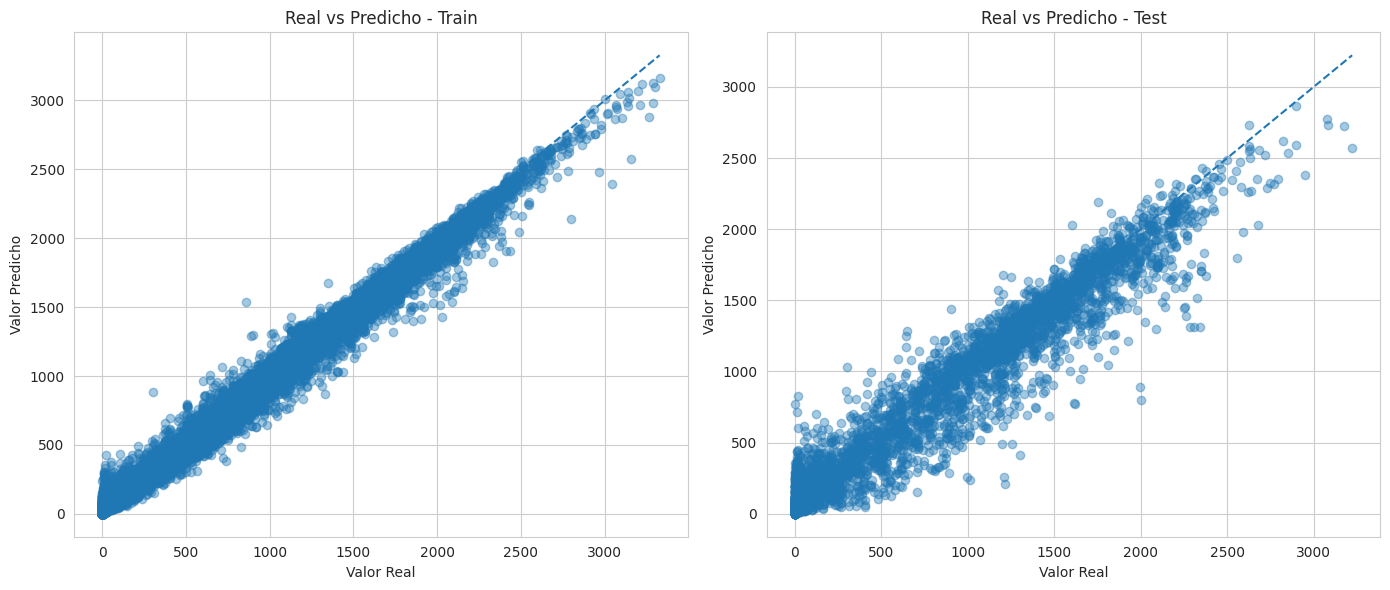

In [72]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].scatter(y_train, y_pred_train, alpha=0.4)
axes[0].plot([y_train.min(), y_train.max()],
             [y_train.min(), y_train.max()],
             linestyle='--')
axes[0].set_title("Real vs Predicho - Train")
axes[0].set_xlabel("Valor Real")
axes[0].set_ylabel("Valor Predicho")

axes[1].scatter(y_test, y_pred_test, alpha=0.4)
axes[1].plot([y_test.min(), y_test.max()],
             [y_test.min(), y_test.max()],
             linestyle='--')
axes[1].set_title("Real vs Predicho - Test")
axes[1].set_xlabel("Valor Real")
axes[1].set_ylabel("Valor Predicho")

plt.tight_layout()
plt.show()

# 9. Evaluación de modelos

In [73]:
# Lista de modelos a evaluar
models = {
    "AdaBoost": AdaBoostRegressor(random_state=42),
    "LightGBM": LGBMRegressor(random_state=42),
    "XGBoost": XGBRegressor(random_state=42, verbosity=0)
}

# Función para calcular métricas
def get_metrics(y_true, y_pred):
    return {
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "MAE": mean_absolute_error(y_true, y_pred),
        "R2": r2_score(y_true, y_pred)
    }

# Lista para guardar resultados
results = []

# Entrenamiento y evaluación
for name, model in models.items():
    model.fit(X_train_encoded_df, y_train)

    # Predicciones
    y_train_pred = model.predict(X_train_encoded_df)
    y_test_pred = model.predict(X_test_encoded_df)

    # Métricas Train
    train_metrics = get_metrics(y_train, y_train_pred)
    train_metrics.update({"Modelo": name, "Conjunto": "Train"})
    results.append(train_metrics)

    # Métricas Test
    test_metrics = get_metrics(y_test, y_test_pred)
    test_metrics.update({"Modelo": name, "Conjunto": "Test"})
    results.append(test_metrics)

# Convertir resultados a DataFrame
metrics_df = pd.DataFrame(results)[["Modelo", "Conjunto", "RMSE", "MAE", "R2"]]

# Mostrar resultados
metrics_df

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.006261 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3367
[LightGBM] [Info] Number of data points in the train set: 21043, number of used features: 39
[LightGBM] [Info] Start training from score 653.172419


,Modelo,Conjunto,RMSE,MAE,R2
0,AdaBoost,Train,586.526772,506.989668,0.350732
1,AdaBoost,Test,591.182680,509.870178,0.330956
2,LightGBM,Train,135.134251,95.394581,0.965535
3,LightGBM,Test,160.955768,112.848072,0.950407
4,XGBoost,Train,93.049923,67.490228,0.983659
5,XGBoost,Test,158.442590,112.996709,0.951943


Al comparar los modelos anteriores con randomforestregressor se derivan las siguientes conclusiones:

 * El modelo AdaBoost es el modelo con mayor error en test y train, tambien tiene un r2 menor que los otros modelos.

 * Los modelos LightGBM y XGBoost tienen mayor error en train que random forest pero predicen con menor error los datos nuevos ya que tienen menos error en test. Ambos también tienen similares r2.

 * El modelo random forest como se menciono anteriormente presenta overfitting

Por lo cual se procede a definir el modelo XGBoost como el mas adecuado debido a menor RMSE y mayor r2


# 10. Mejoras - Tuning de hiperparámetros

In [ ]:
# Estimador base
estimatorXGB = XGBRegressor(random_state=42)

# Espacio de búsqueda
search_space = {
    "n_estimators": (100, 500), #num árboles
    "max_depth": (3, 10), #profundidad máx árbol
    "learning_rate": (0.01, 0.3, 'log-uniform'),
    "subsample": (0.5, 1.0), #Fracción de datos utilizados
    "colsample_bytree": (0.5, 1.0),
    "reg_alpha": (0.0, 5.0),
    "reg_lambda": (0.0, 5.0),
}

# Búsqueda bayesiana

bayes_search = BayesSearchCV(
    estimator=XGBRegressor(random_state=42, n_jobs=-1),
    search_spaces=search_space,
    n_iter=30,
     cv=5,
    scoring='neg_root_mean_squared_error',
    random_state=42,
    n_jobs=-1,
    verbose=0
)

bayes_search.fit(X_train_encoded_df, y_train)

# Mejor modelo
best_model = bayes_search.best_estimator_

In [ ]:
best_params = bayes_search.best_params_
print(best_params)

In [ ]:
print(best_model.get_params())

In [ ]:
# Predicciones
y_pred_train = best_model.predict(X_train_encoded_df)
y_pred_test = best_model.predict(X_test_encoded_df)

In [ ]:
resultados = [
    {"Modelo": "XGBoost Tuned", "Conjunto": "Train", **get_metrics(y_train, y_pred_train)},
    {"Modelo": "XGBoost Tuned", "Conjunto": "Test", **get_metrics(y_test, y_pred_test)},
]

pd.DataFrame(resultados)

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].scatter(y_train, y_pred_train, alpha=0.4)
axes[0].plot([y_train.min(), y_train.max()],
             [y_train.min(), y_train.max()],
             linestyle='--')
axes[0].set_title("Real vs Predicho - Train")
axes[0].set_xlabel("Valor Real")
axes[0].set_ylabel("Valor Predicho")

axes[1].scatter(y_test, y_pred_test, alpha=0.4)
axes[1].plot([y_test.min(), y_test.max()],
             [y_test.min(), y_test.max()],
             linestyle='--')
axes[1].set_title("Real vs Predicho - Test")
axes[1].set_xlabel("Valor Real")
axes[1].set_ylabel("Valor Predicho")

plt.tight_layout()
plt.show()

El modelo mejorado XGBoost Tuned, logra reducir la métrica MAE un 38% en Train y un 22% en test.

# 10. Modelo Final y conclusiones

In [ ]:
best_params = best_model.get_params()

In [ ]:
#Mejor modelo y parámetros
best_model = XGBRegressor(**best_params)
best_model

In [ ]:
X = pd.concat([X_train_encoded_df, X_test_encoded_df], axis=0).reset_index(drop=True)
y = pd.concat([y_train, y_test], axis=0).reset_index(drop=True)

In [ ]:
best_model.fit(X, y)

Se utiliza validación cruzada para evitar el overfitting.


In [ ]:
# Defino métricas para cross_validate
scoring = {
    'rmse': make_scorer(lambda y_true, y_pred: np.sqrt(mean_squared_error(y_true, y_pred))),
    'mae': 'neg_mean_absolute_error',
    'r2': 'r2'
}

# cross_validate (devuelve diccionario con test_score para cada métrica y fold)
cv_results = cross_validate(
    best_model, X, y,
    cv=5, # 5 partes
    scoring=scoring,
    return_train_score=False
)

# Organizo resultados por fold en DataFrame
results_df = pd.DataFrame({
    'Fold': range(1, 6),
    'RMSE': cv_results['test_rmse'],
    'MAE': -cv_results['test_mae'],  # invertir signo
    'R2': cv_results['test_r2']
})

results_df

El modelo muestra buen rendimiento, con métricas MAE similares alrededor del 84 MWh , valores similares de r2 en mayoría de los folds, cercanos a 0,97.

Como conclusión el mejor modelo es XGBRegressor con best_params para estimar la variable IMPORTACION